In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import glob
import numpy as np
from IPython.display import display
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from plot_func import *

In [6]:
geo = pd.read_csv('/mnt/scratch/baburish/doublepulse/stringv2/geometry_clean.csv', delimiter=',')
print(len(geo))
X = geo['dom_x']
Y = geo['dom_y']
Z = geo['dom_z']
string=geo['string']

# plot_detector_geometry(geo)

5160


In [7]:
def load_db(db_file):
    conn = sqlite3.connect(db_file)
    df_truth = pd.read_sql_query("""
        SELECT event_no, energy, pid,
               position_x, position_y, position_z,
               azimuth, zenith
        FROM truth;
    """, conn)
    df_pulses = pd.read_sql_query(
        "SELECT event_no, dom_x, dom_y, dom_z, dom_time, charge FROM CleanedROIPulses;",
        conn
    )
    conn.close()
    df = df_pulses.merge(df_truth, on="event_no", how="inner")
    return df

In [8]:
# df_nue   = load_db("/mnt/scratch/baburish/doublepulse/gnn/files/output/nue/nue_pisces_65TeV_lowerbound_skimmed_chunk_022857.023933_0000.db")
# df_nutau = load_db("/mnt/scratch/baburish/doublepulse/gnn/files/output/nutau/nutau_pisces_65TeV_lowerbound_skimmed_chunk_022859.000147_0000.db")

#low energy 
df_nue   = load_db("/mnt/scratch/baburish/doublepulse/gnn/files/output/nue/nue_pisces_5TeV_lowerbound_skimmed_chunk_022856.000009_0000.db")
df_nutau = load_db("/mnt/scratch/baburish/doublepulse/gnn/files/output/nutau/nutau_pisces_5TeV_lowerbound_skimmed_chunk_022859.000147_0000.db")

print("nue events:", df_nue.event_no.nunique())
print("nutau events:", df_nutau.event_no.nunique())

nue events: 875
nutau events: 935


In [5]:
def group_events(df):
    return dict(tuple(df.groupby("event_no")))

events_nue = group_events(df_nue)
events_tau = group_events(df_nutau)

In [ ]:
df_nutau.head()

,event_no,dom_x,dom_y,dom_z,dom_time,charge,energy,pid,position_x,position_y,position_z,azimuth,zenith
0,0,371.56,-92.18,281.31,1173.0,0.575,73912.196236,-16.0,4626.982797,6427.993503,1943.079481,0.979814,1.341101
1,0,371.56,-92.18,247.27,1207.0,0.225,73912.196236,-16.0,4626.982797,6427.993503,1943.079481,0.979814,1.341101
2,0,371.56,-92.18,229.25,1250.0,0.425,73912.196236,-16.0,4626.982797,6427.993503,1943.079481,0.979814,1.341101
3,0,371.56,-92.18,213.23,1055.0,1.175,73912.196236,-16.0,4626.982797,6427.993503,1943.079481,0.979814,1.341101
4,0,371.56,-92.18,213.23,1083.0,0.725,73912.196236,-16.0,4626.982797,6427.993503,1943.079481,0.979814,1.341101


In [7]:
def build_event_summary(events):
    """
    For each event, collect all DOM hits as lists (x, y, z, time, charge)
    plus scalar truth info (energy, pid).
    """
    rows = []
    for eid, ev in events.items():
        rows.append({
            "event_no":  eid,
            "energy":    ev.energy.iloc[0],
            "pid":       ev.pid.iloc[0],
            "dom_x":     ev.dom_x.tolist(),
            "dom_y":     ev.dom_y.tolist(),
            "dom_z":     ev.dom_z.tolist(),
            "dom_time":  ev.dom_time.tolist(),
            "charge":    ev.charge.tolist(),
            "n_hits":    len(ev),
        })
    return pd.DataFrame(rows).set_index("event_no")

summary_nue = build_event_summary(events_nue)
summary_tau = build_event_summary(events_tau)

print(summary_nue.shape)
print(summary_tau.shape)
display(summary_tau.head())

(875, 8)
(935, 8)


,energy,pid,dom_x,dom_y,dom_z,dom_time,charge,n_hits
event_no,,,,,,,,
0,73912.196236,-16.0,"[371.56, 371.56, 371.56, 371.56, 371.56, 371.5...","[-92.18, -92.18, -92.18, -92.18, -92.18, -92.1...","[281.31, 247.27, 229.25, 213.23, 213.23, 213.2...","[1173.0, 1207.0, 1250.0, 1055.0, 1083.0, 1106....","[0.574999988079071, 0.22499999403953552, 0.425...",1605
1,33801.519326,16.0,"[35.54, 35.54, 35.54, 158.94, 158.94, 158.94, ...","[-364.83, -364.83, -364.83, -345.23, -345.23, ...","[-319.28, -336.3, -336.3, -300.14, -334.18, -3...","[1846.0, 1123.0, 1589.0, 1604.0, 1492.0, 1498....","[0.675000011920929, 0.32499998807907104, 1.125...",1638
2,33088.706689,-16.0,"[-156.23, -156.23, -156.23, -156.23, -156.23, ...","[43.37, 43.37, 43.37, 43.37, 43.37, 43.37, 43....","[245.52, 228.5, 194.46, 160.42, 143.4, 143.4, ...","[972.0, 1111.0, 1238.0, 1186.0, 740.0, 1038.0,...","[0.824999988079071, 1.5750000476837158, 0.5249...",738
3,125863.927917,16.0,"[-334.8, -334.8, -334.8, -334.8, -413.46, -413...","[-424.5, -424.5, -424.5, -424.5, -327.27, -327...","[-316.4, -350.44, -350.44, -367.46, -147.19, -...","[1135.0, 862.0, 1749.0, 1710.0, 1971.0, 1308.0...","[0.675000011920929, 1.274999976158142, 1.22500...",978
4,12791.128449,16.0,"[174.47, 174.47, 174.47, 303.41, 303.41, 303.4...","[315.54, 315.54, 315.54, 335.64, 335.64, 335.6...","[325.52, 308.5, 274.45, 393.81, 376.79, 376.79...","[464.0, 295.0, 588.0, 354.0, 208.0, 507.0, 117...","[0.7250000238418579, 0.22499999403953552, 0.82...",259


In [8]:
# Pick one tau event
eid = list(events_tau.keys())[0]
ev = events_tau[eid]

# Find the DOM with max charge
max_idx = ev.charge.idxmax()
max_row = ev.loc[max_idx]

print(f"Event: {eid}")
print(f"Max charge DOM:")
print(f"  x = {max_row.dom_x:.2f} m")
print(f"  y = {max_row.dom_y:.2f} m")
print(f"  z = {max_row.dom_z:.2f} m")
print(f"  time   = {max_row.dom_time:.2f} ns")
print(f"  charge = {max_row.charge:.4f} PE")

Event: 0
Max charge DOM:
  x = 411.81 m
  y = 13.00 m
  z = 161.32 m
  time   = 58.00 ns
  charge = 12.3750 PE


In [9]:
# Pick one tau event
eid = list(events_tau.keys())[0]
ev = events_tau[eid]

# Sum charge per DOM (a DOM can have multiple hits)
dom_charge = (
    ev.groupby(["dom_x", "dom_y", "dom_z"])["charge"]
    .sum()
    .reset_index()
    .rename(columns={"charge": "total_charge"})
    .sort_values("total_charge", ascending=False)
    .reset_index(drop=True)
)

display(dom_charge)

,dom_x,dom_y,dom_z,total_charge
0,411.81,13.00,161.32,279.575001
1,330.03,127.20,143.43,269.375001
2,330.03,127.20,160.45,268.350001
3,411.81,13.00,127.28,207.950000
4,411.81,13.00,178.34,199.525001
...,...,...,...,...
131,371.56,-92.18,229.25,0.425000
132,472.05,127.90,10.67,0.425000
133,292.90,5.20,287.16,0.375000
134,371.56,-92.18,247.27,0.225000


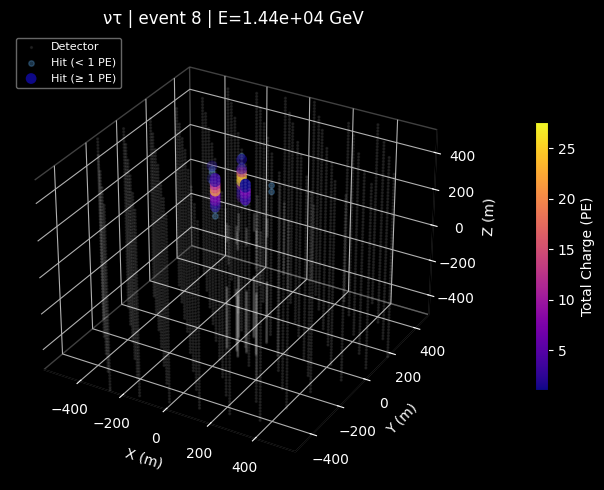

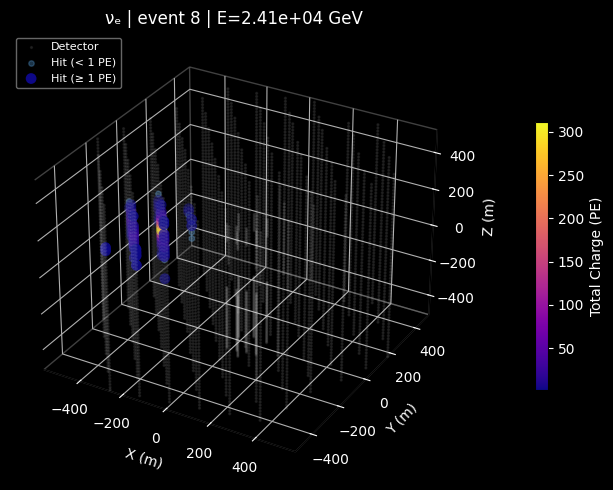

In [10]:
eid_tau = list(events_tau.keys())[8]
eid_nue = list(events_nue.keys())[8]
CHARGE_THRESHOLD = 1
plot_doms_above_threshold(
    events_tau[eid_tau], geo,
    threshold=CHARGE_THRESHOLD,
    title=f"ντ | event {eid_tau} | E={events_tau[eid_tau].energy.iloc[0]:.2e} GeV"
)
plot_doms_above_threshold(
    events_nue[eid_nue], geo,
    threshold=CHARGE_THRESHOLD,
    title=f"νₑ | event {eid_nue} | E={events_nue[eid_nue].energy.iloc[0]:.2e} GeV"
)

nue events: 875
nutau events: 935
t0 = -101.00 ns  |  cut at 1399.00 ns


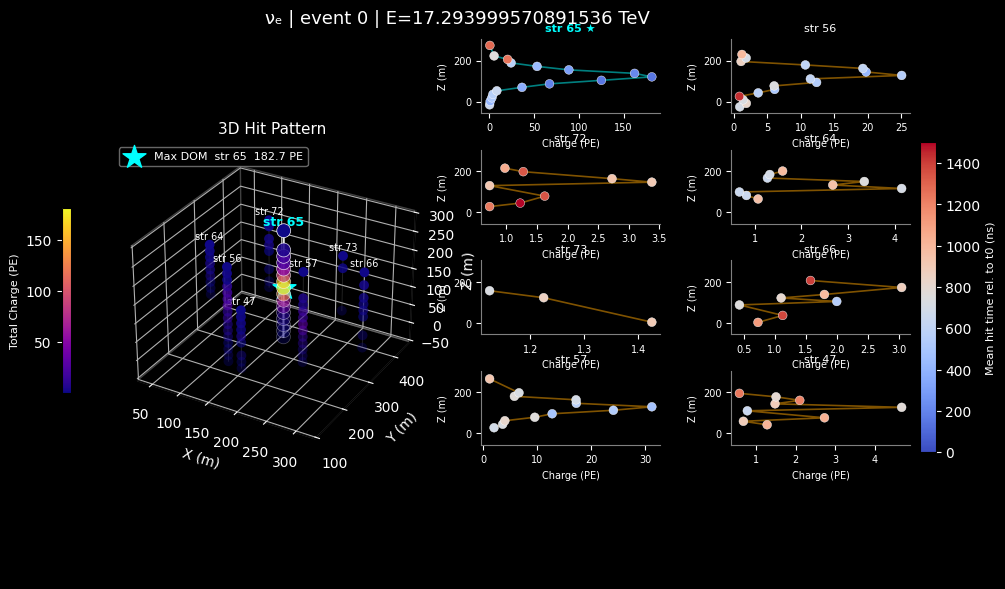

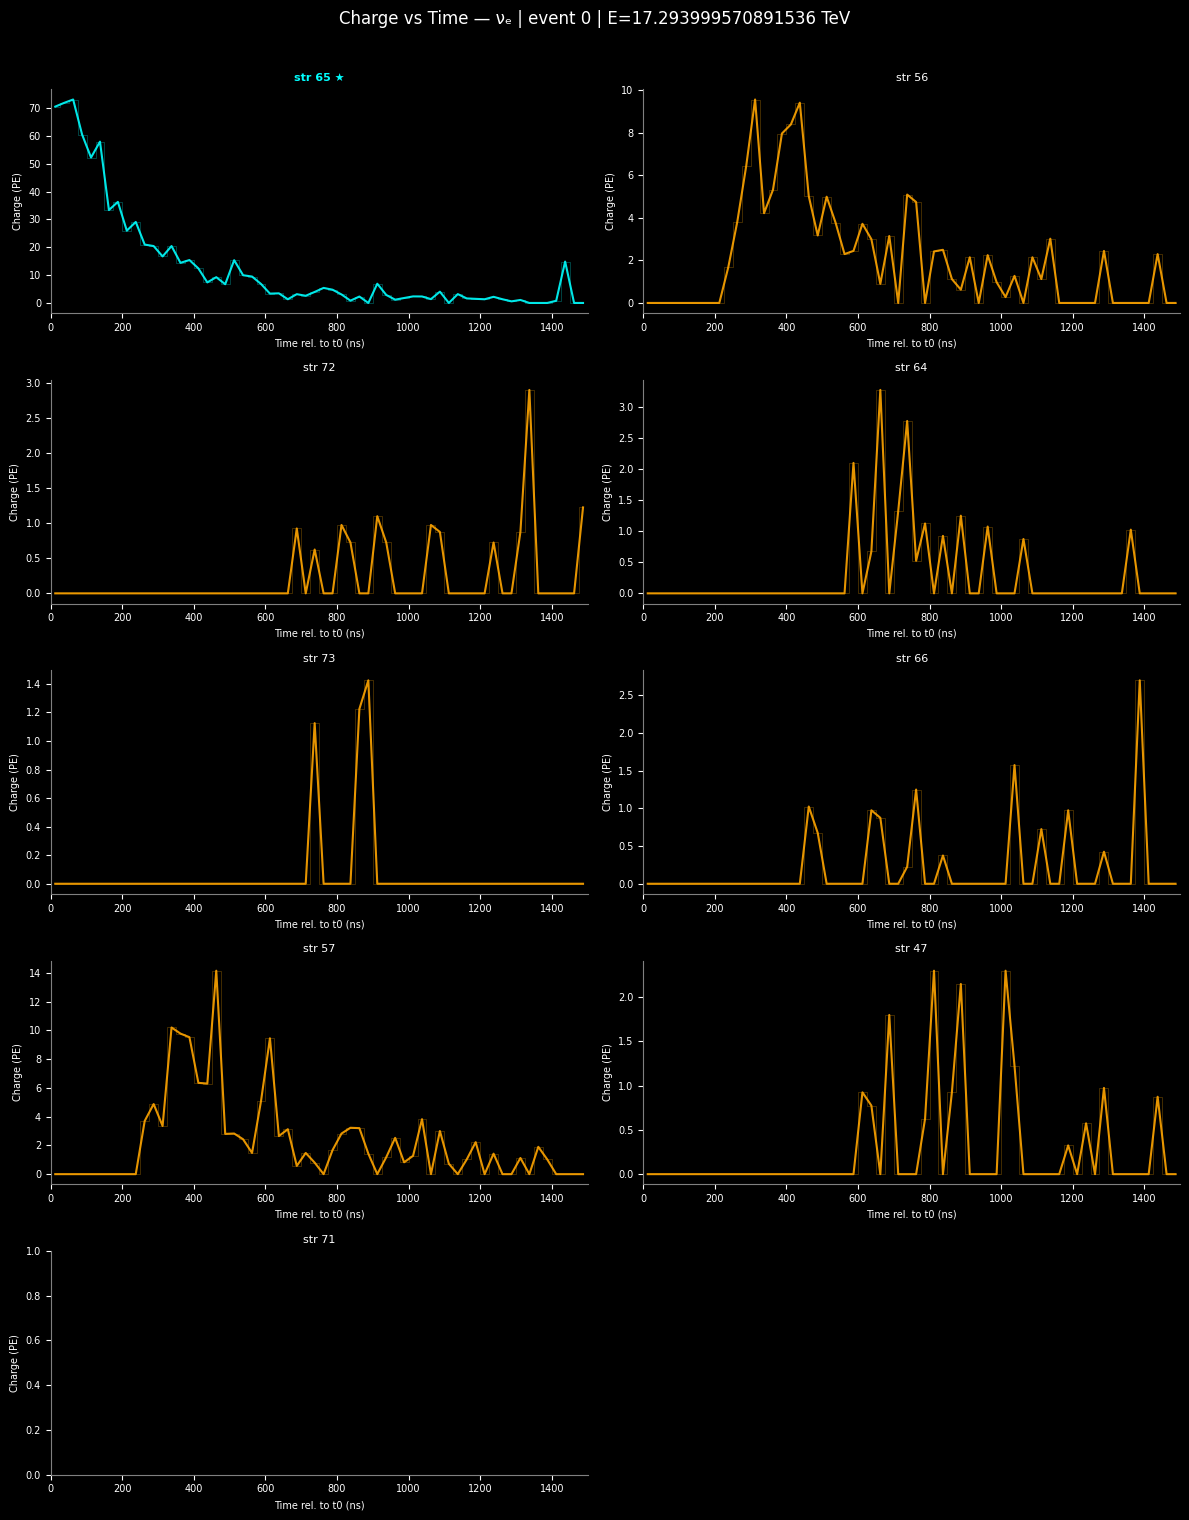

t0 = -117.00 ns  |  cut at 1383.00 ns


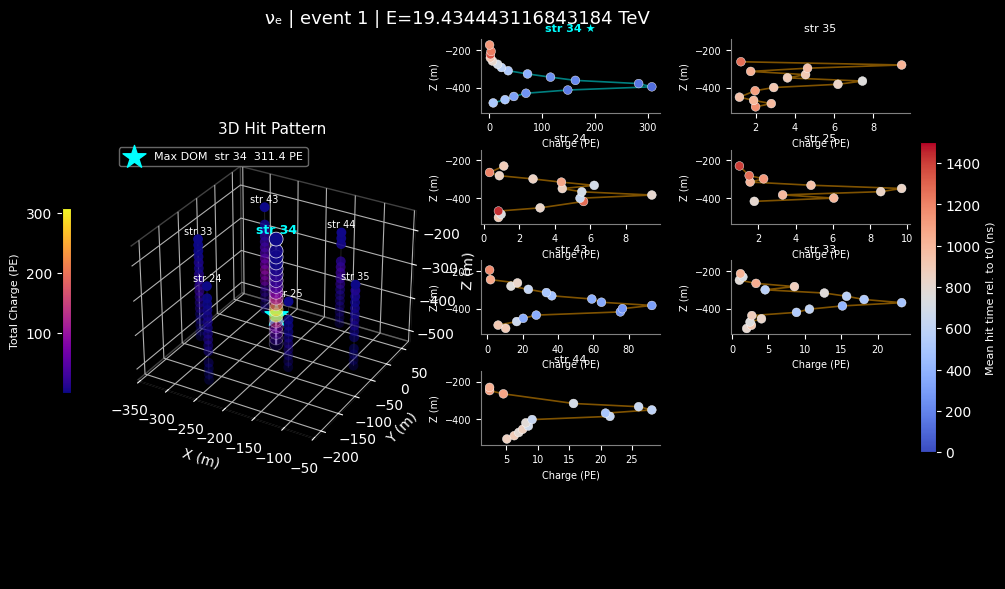

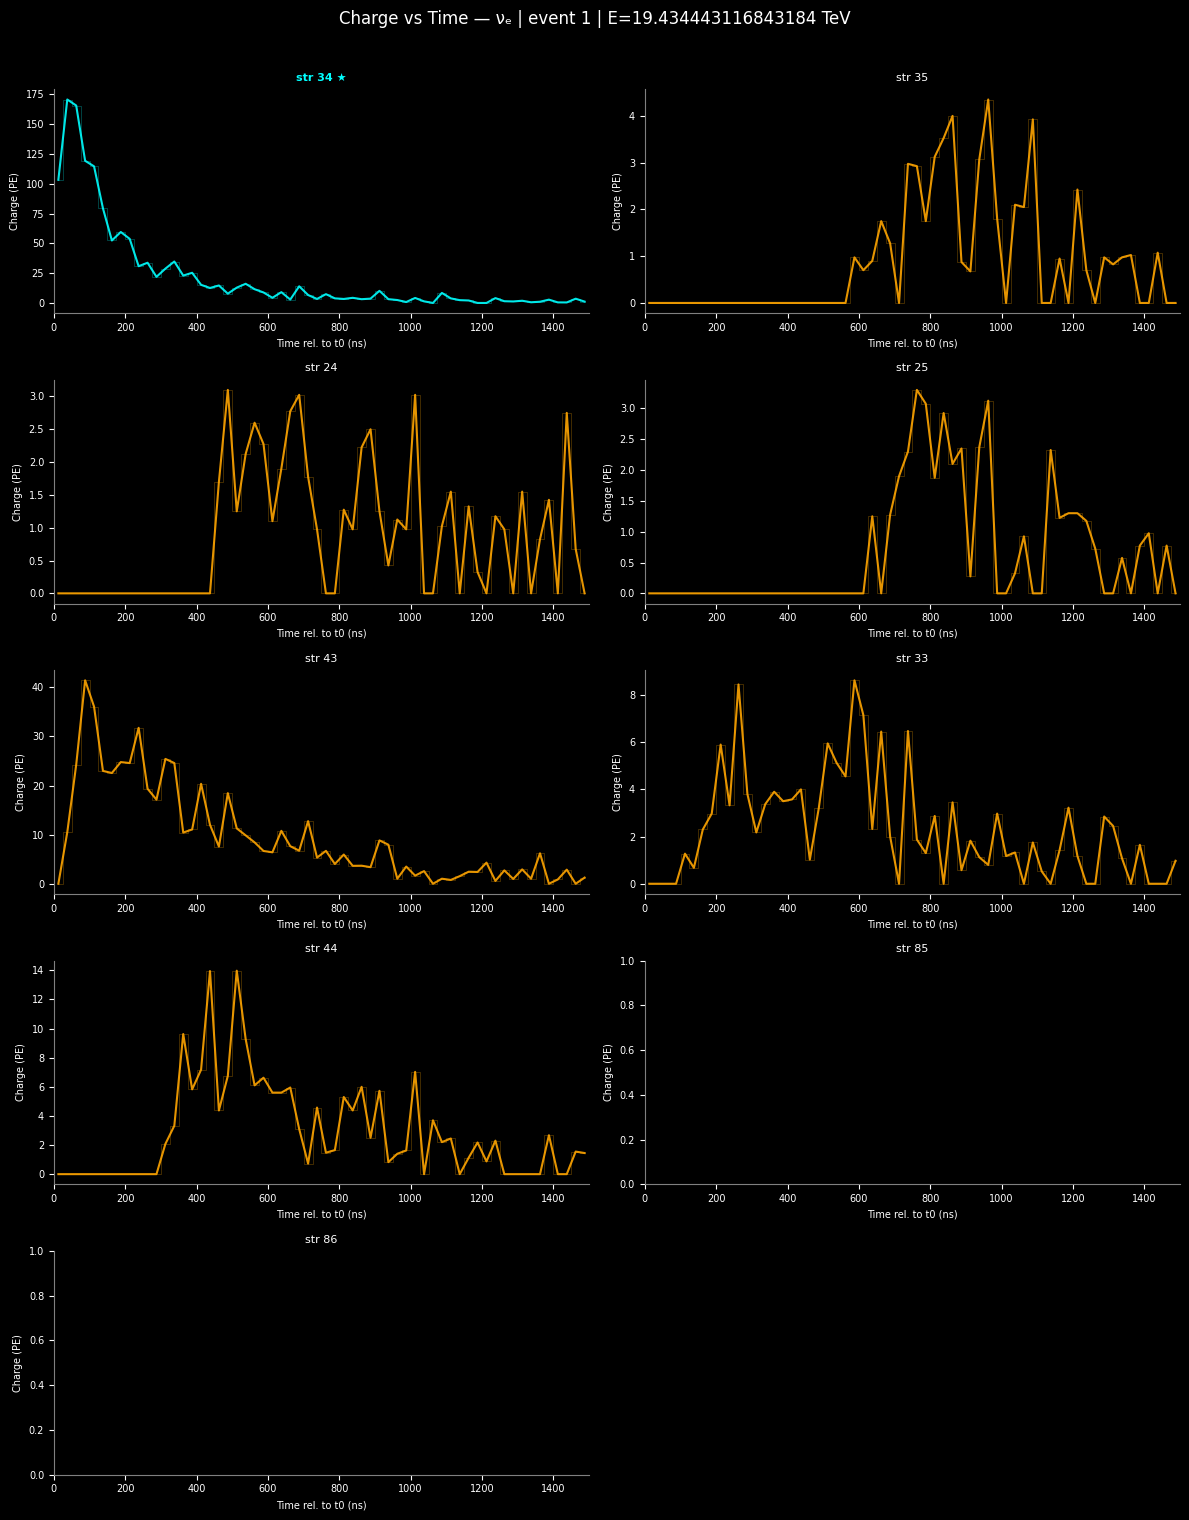

t0 = -92.00 ns  |  cut at 1408.00 ns


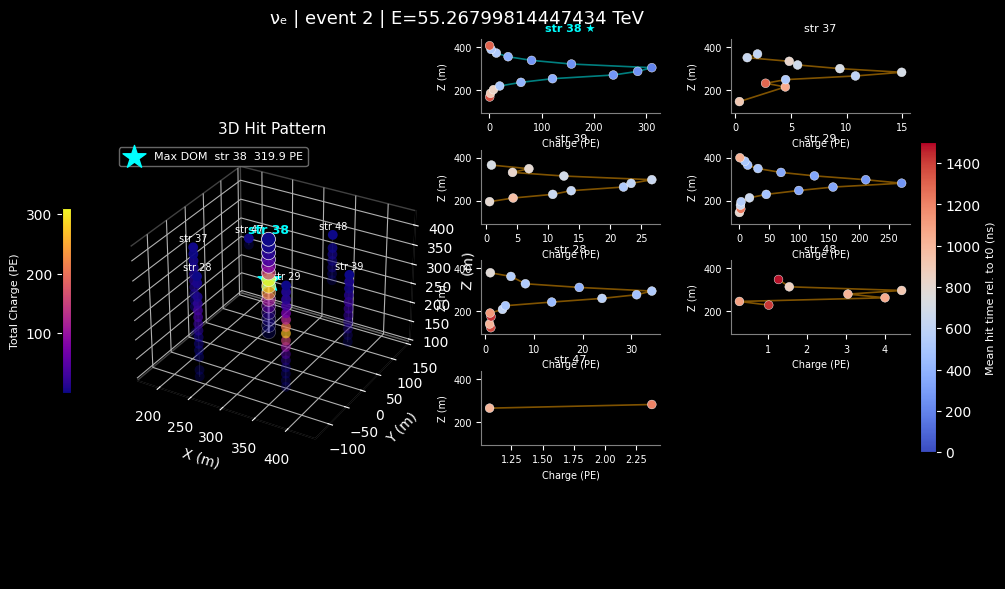

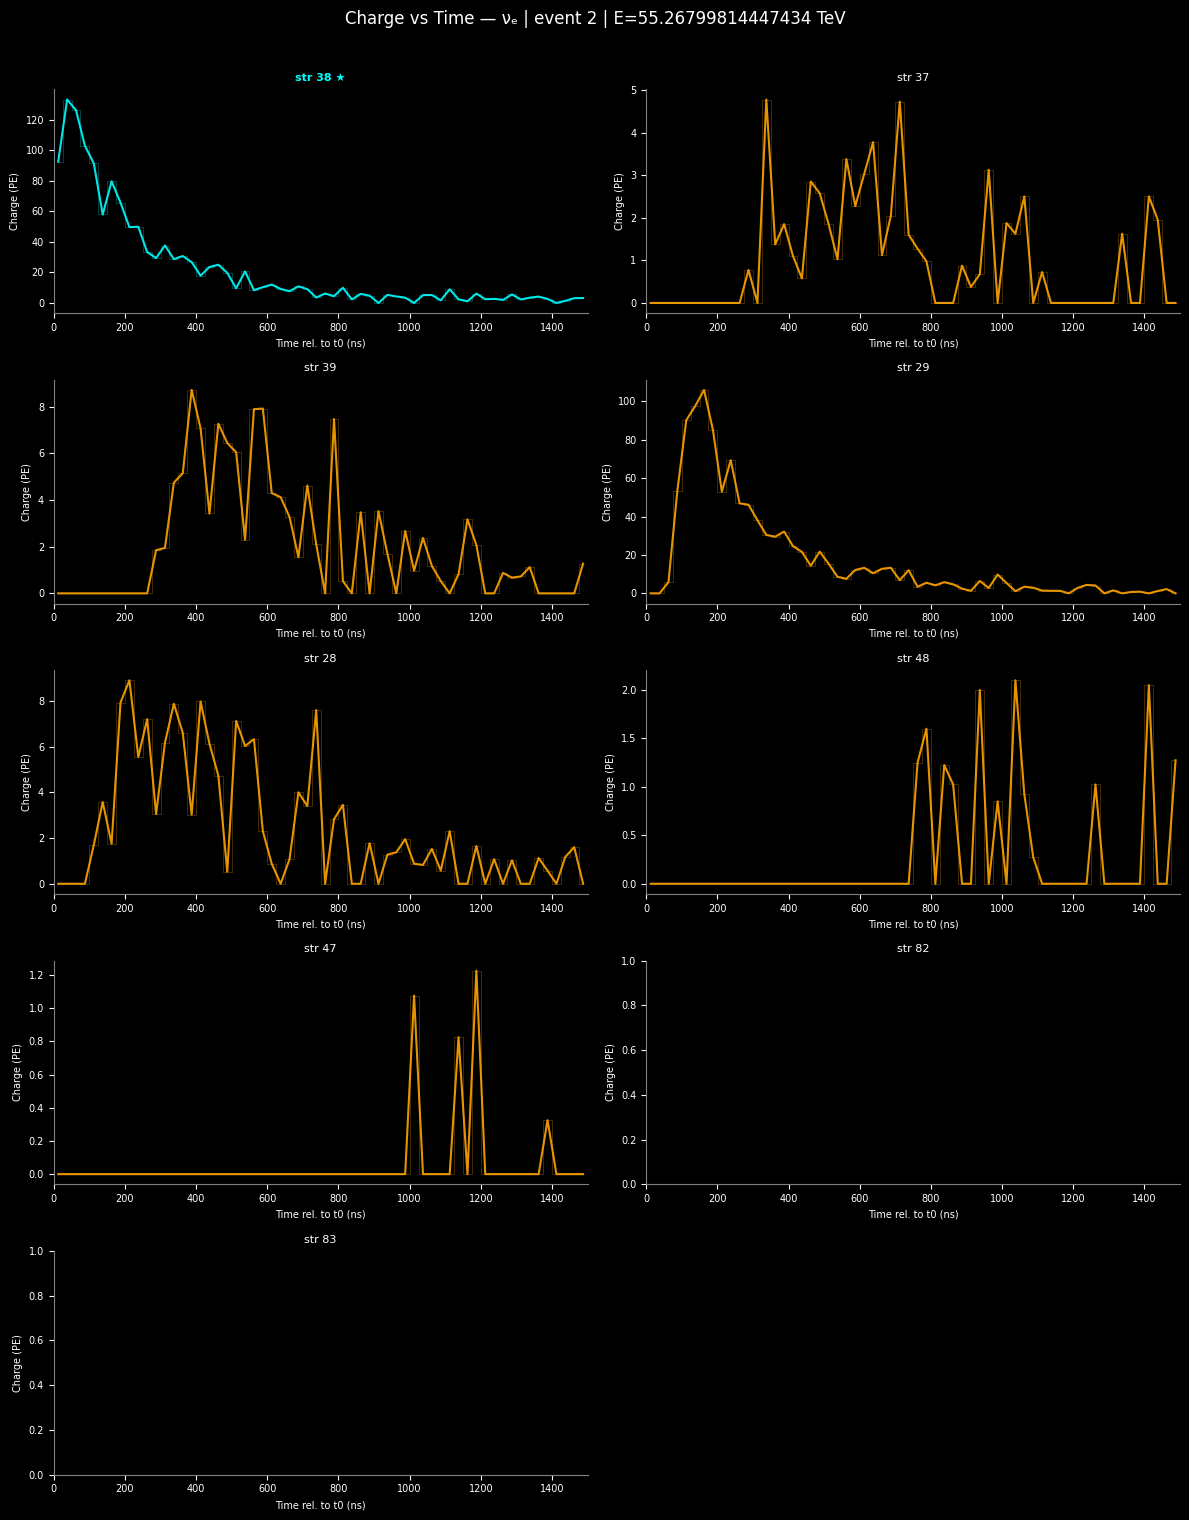

t0 = 107.00 ns  |  cut at 1607.00 ns


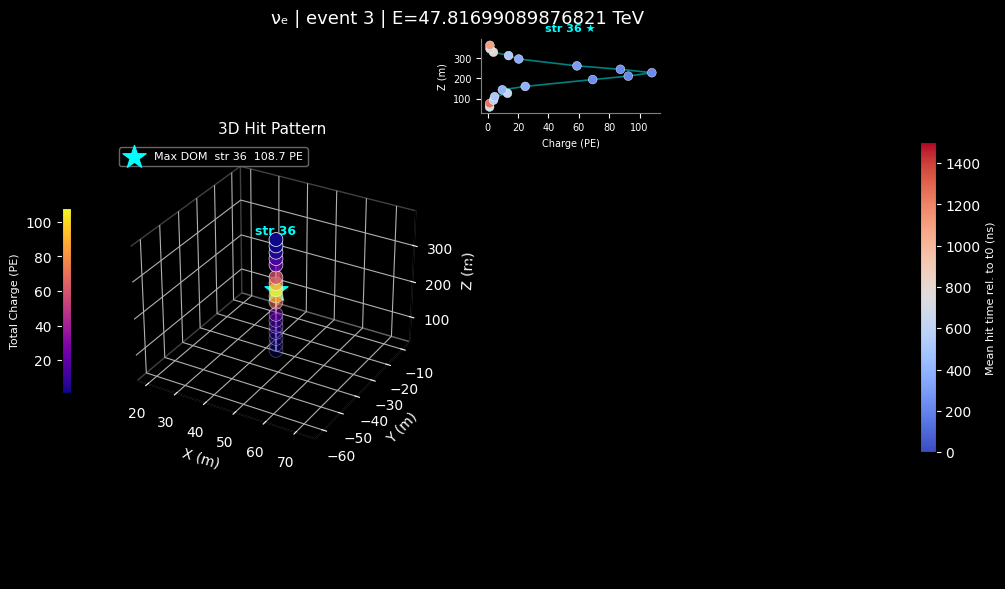

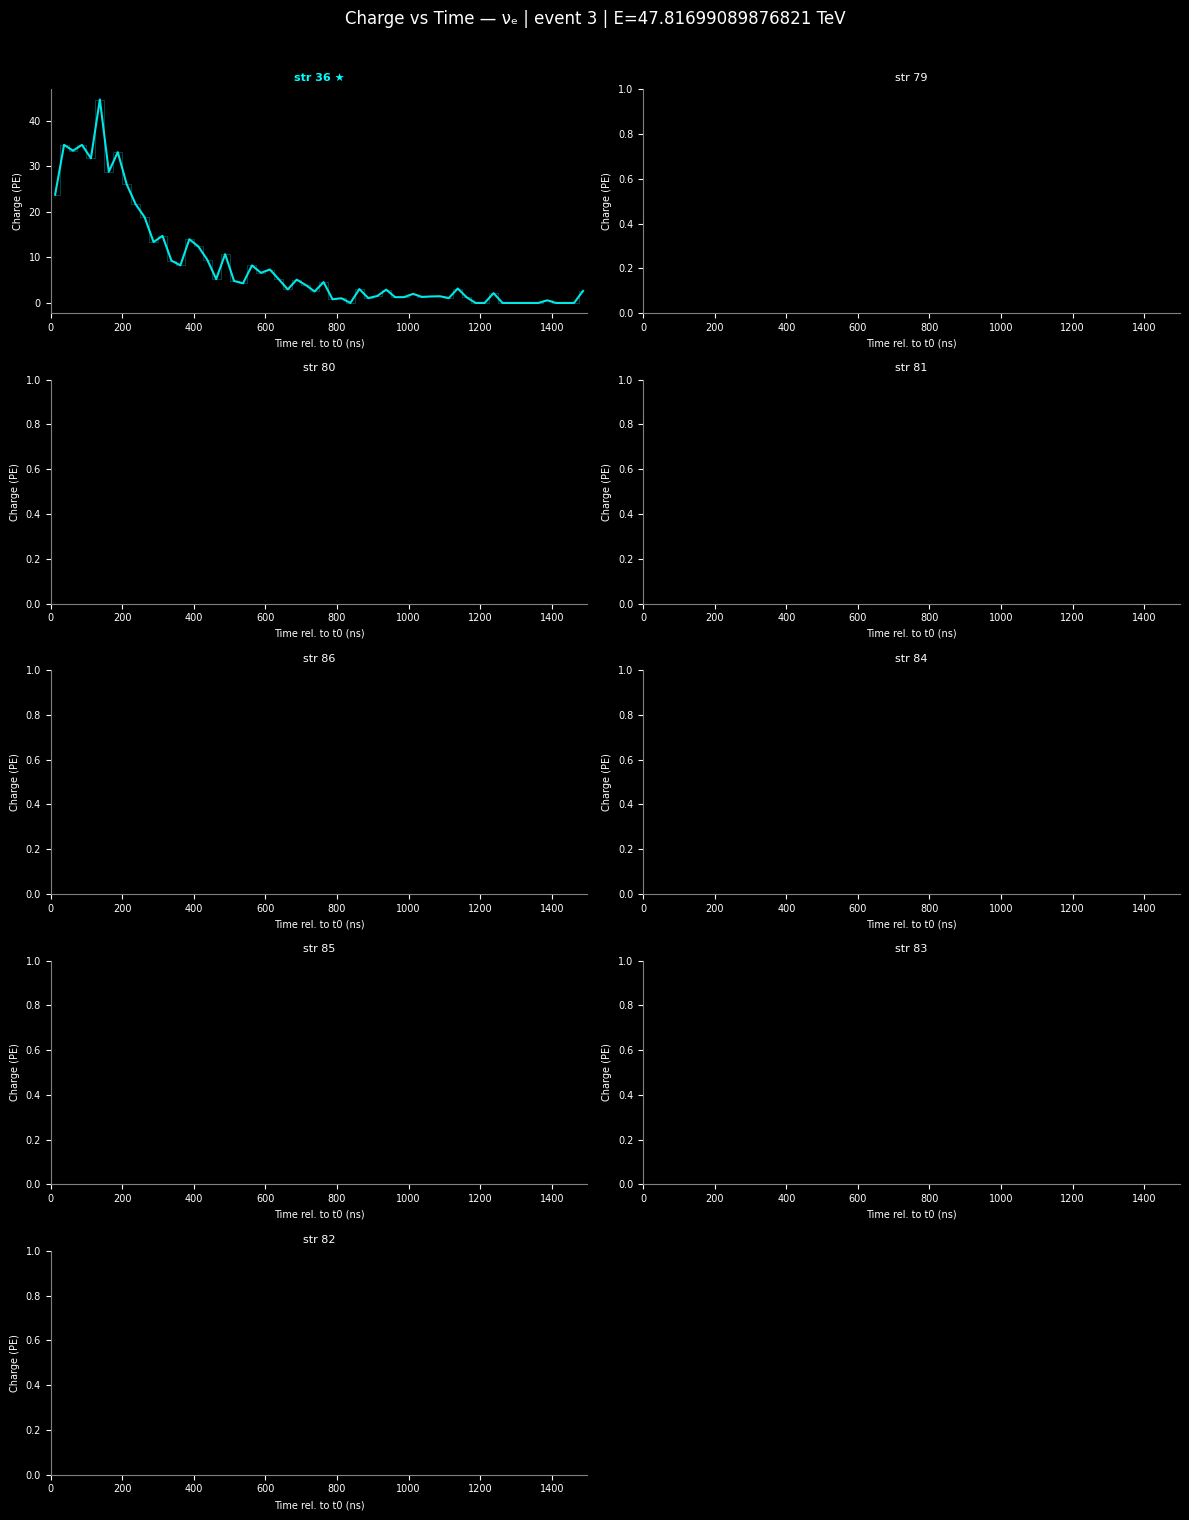

t0 = -96.00 ns  |  cut at 1404.00 ns


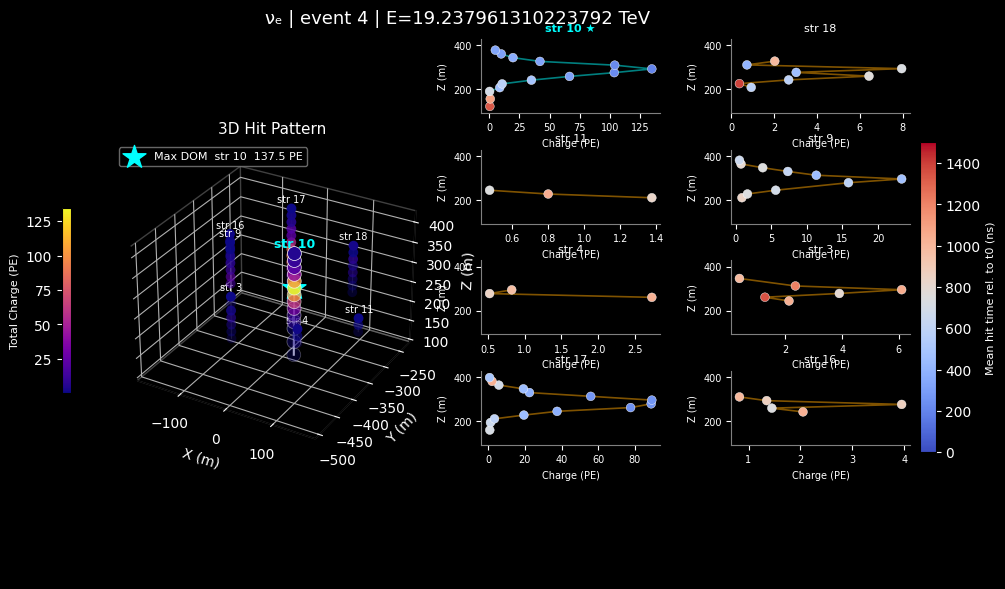

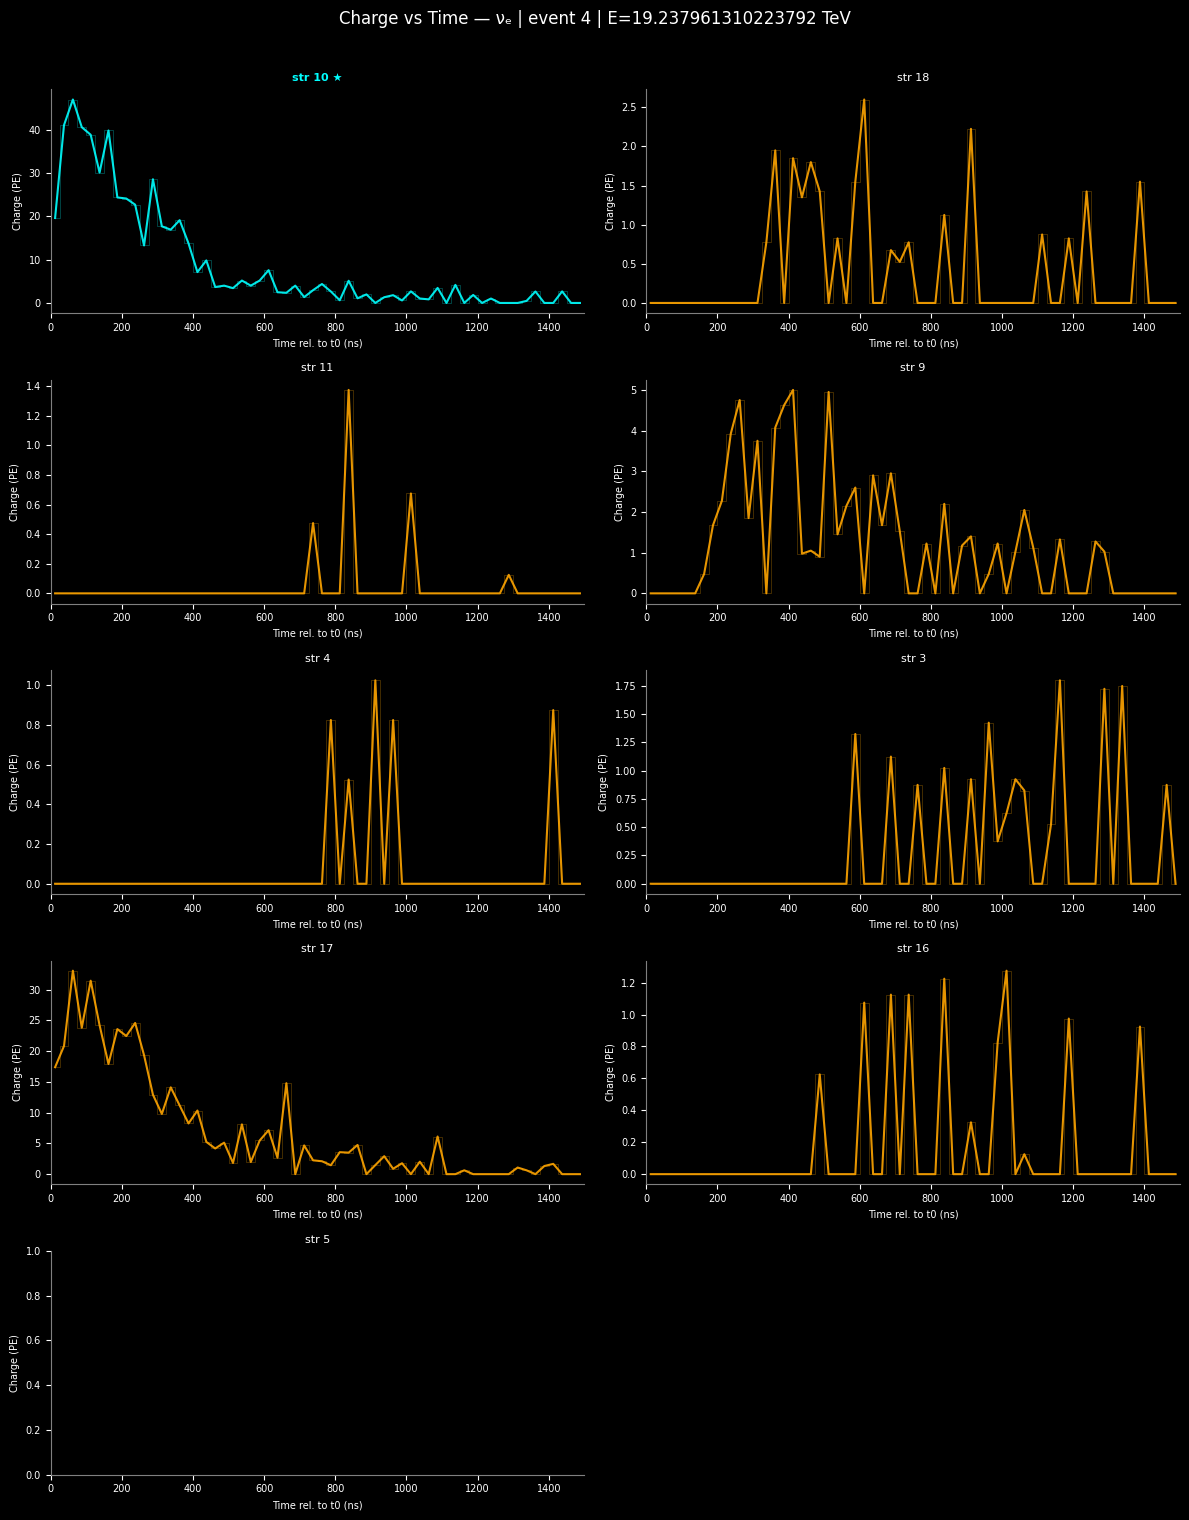

In [ ]:
print("nue events:", df_nue.event_no.nunique())
print("nutau events:", df_nutau.event_no.nunique())
for i in range(0, 5):
    eid_nue = list(events_nue.keys())[i]
    plot_nearest_strings(
    events_nue[eid_nue], geo, n_surrounding=8,
    title=f"νₑ | event {eid_nue} | E={events_nue[eid_nue].energy.iloc[0]/1e3} TeV"
    )
    # plt.savefig(f"Event{i}.png")

# # --- Plot ---
# eid_tau = list(events_tau.keys())[8]
# eid_nue = list(events_nue.keys())[8]

# plot_nearest_strings(
#     events_tau[eid_tau], geo, n_surrounding=8,
#     title=f"ντ | event {eid_tau} | E={events_tau[eid_tau].energy.iloc[0]/1e3} TeV"
# )
# plot_nearest_strings(
#     events_nue[eid_nue], geo, n_surrounding=8,
#     title=f"νₑ | event {eid_nue} | E={events_nue[eid_nue].energy.iloc[0]/1e3} TeV"
# )

nue events: 875
nutau events: 935
t0 = 9.00 ns  |  cut at 1509.00 ns


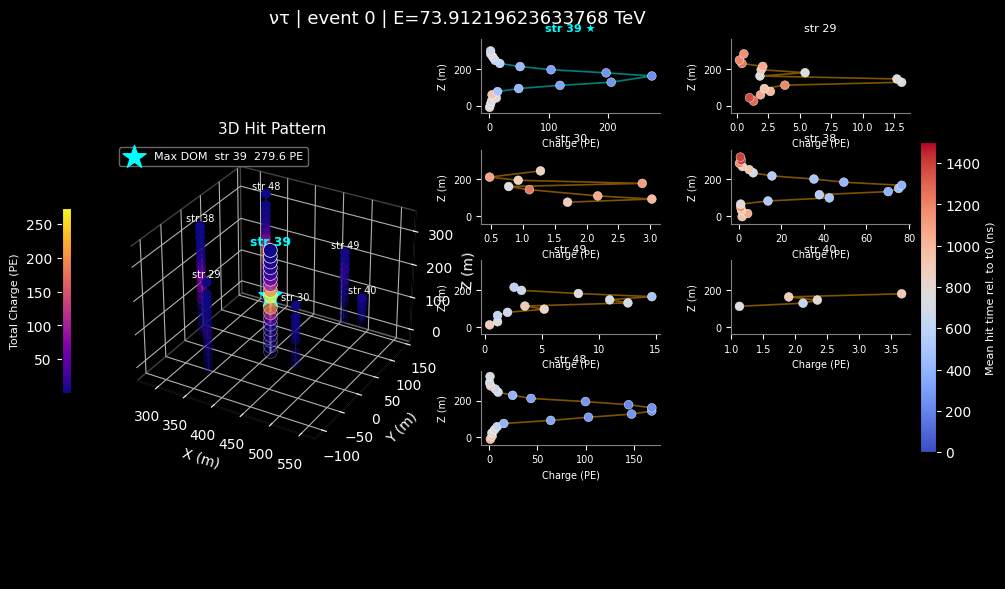

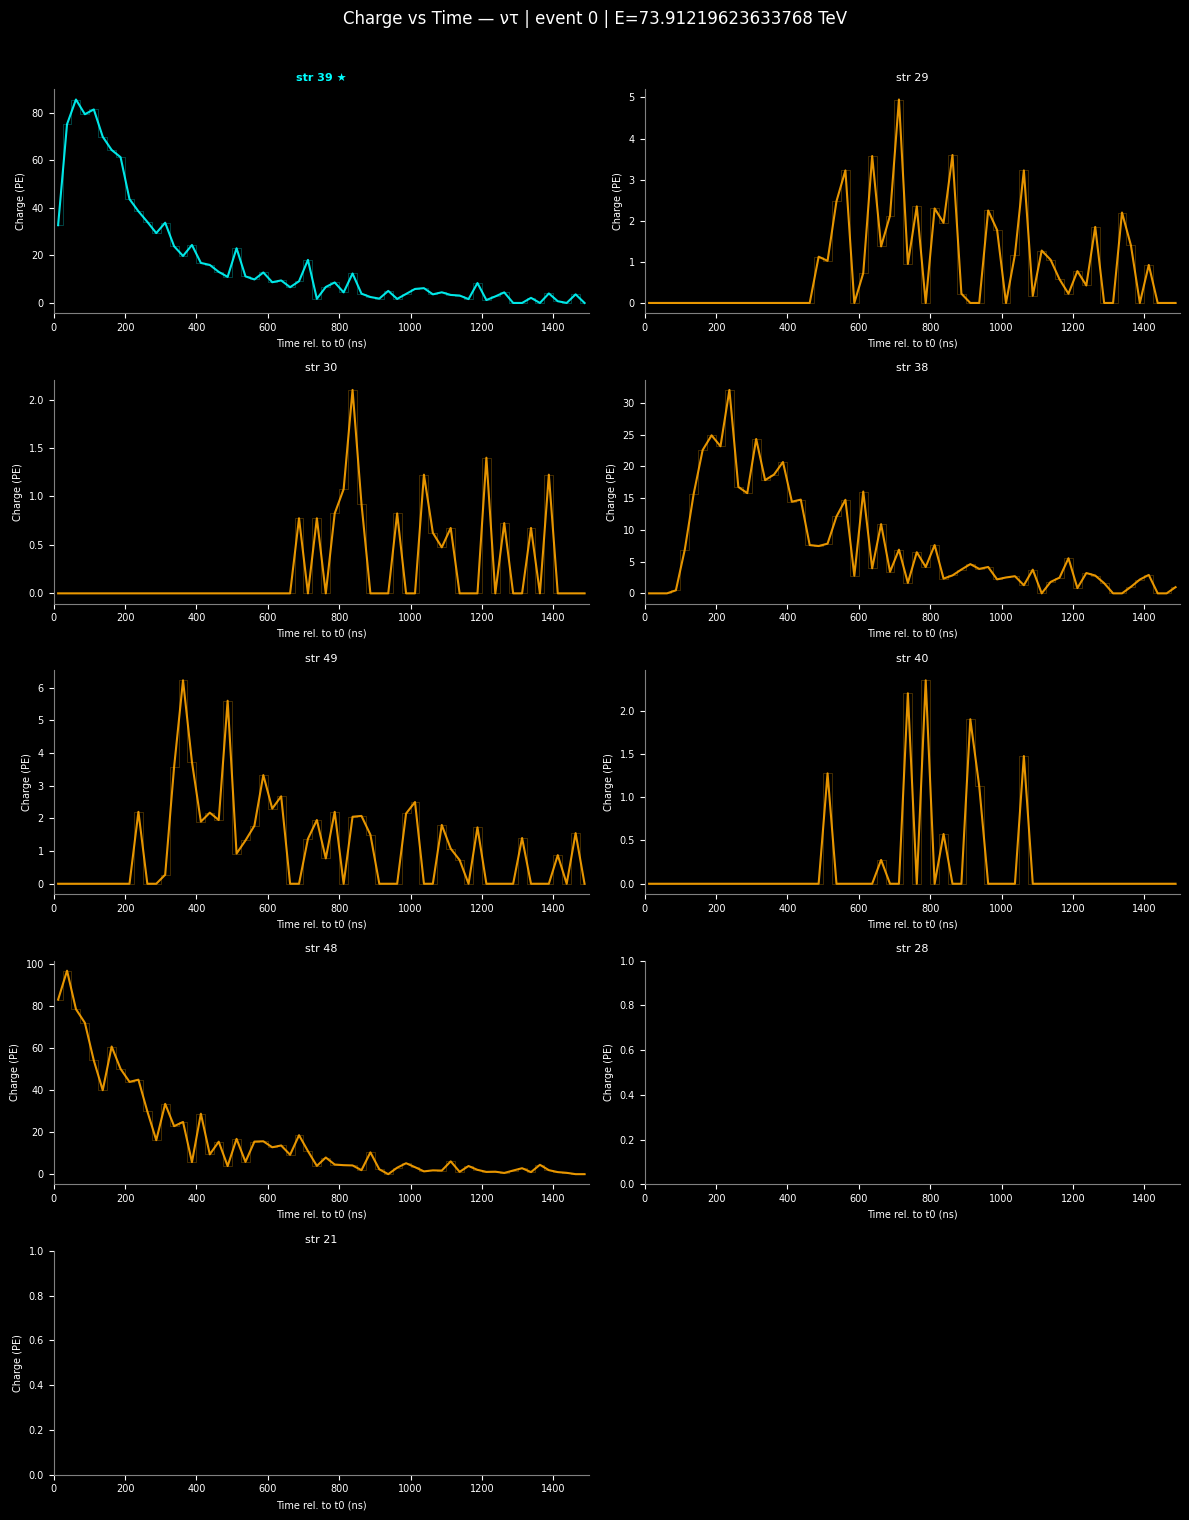

t0 = 10.00 ns  |  cut at 1510.00 ns


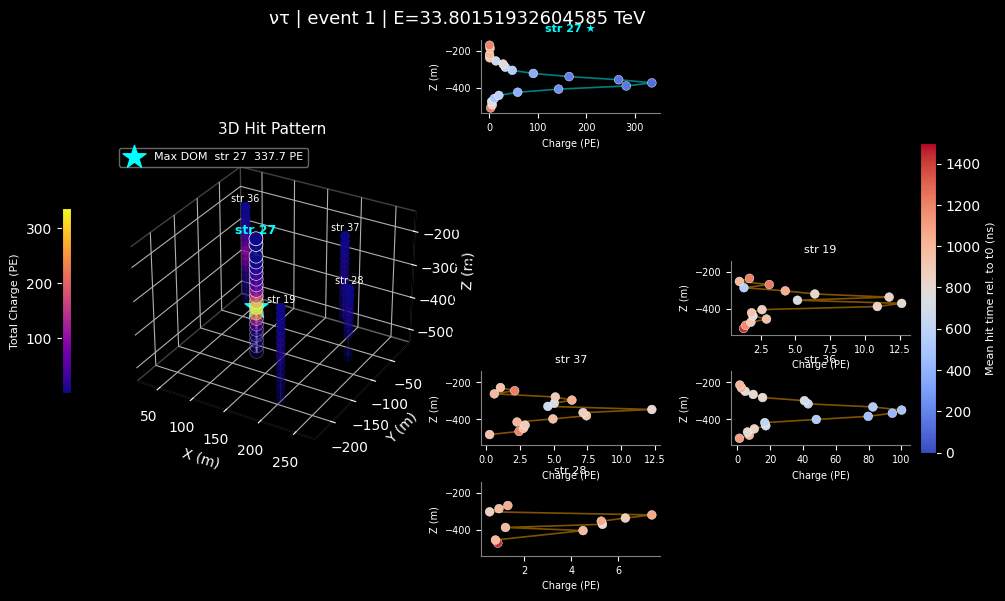

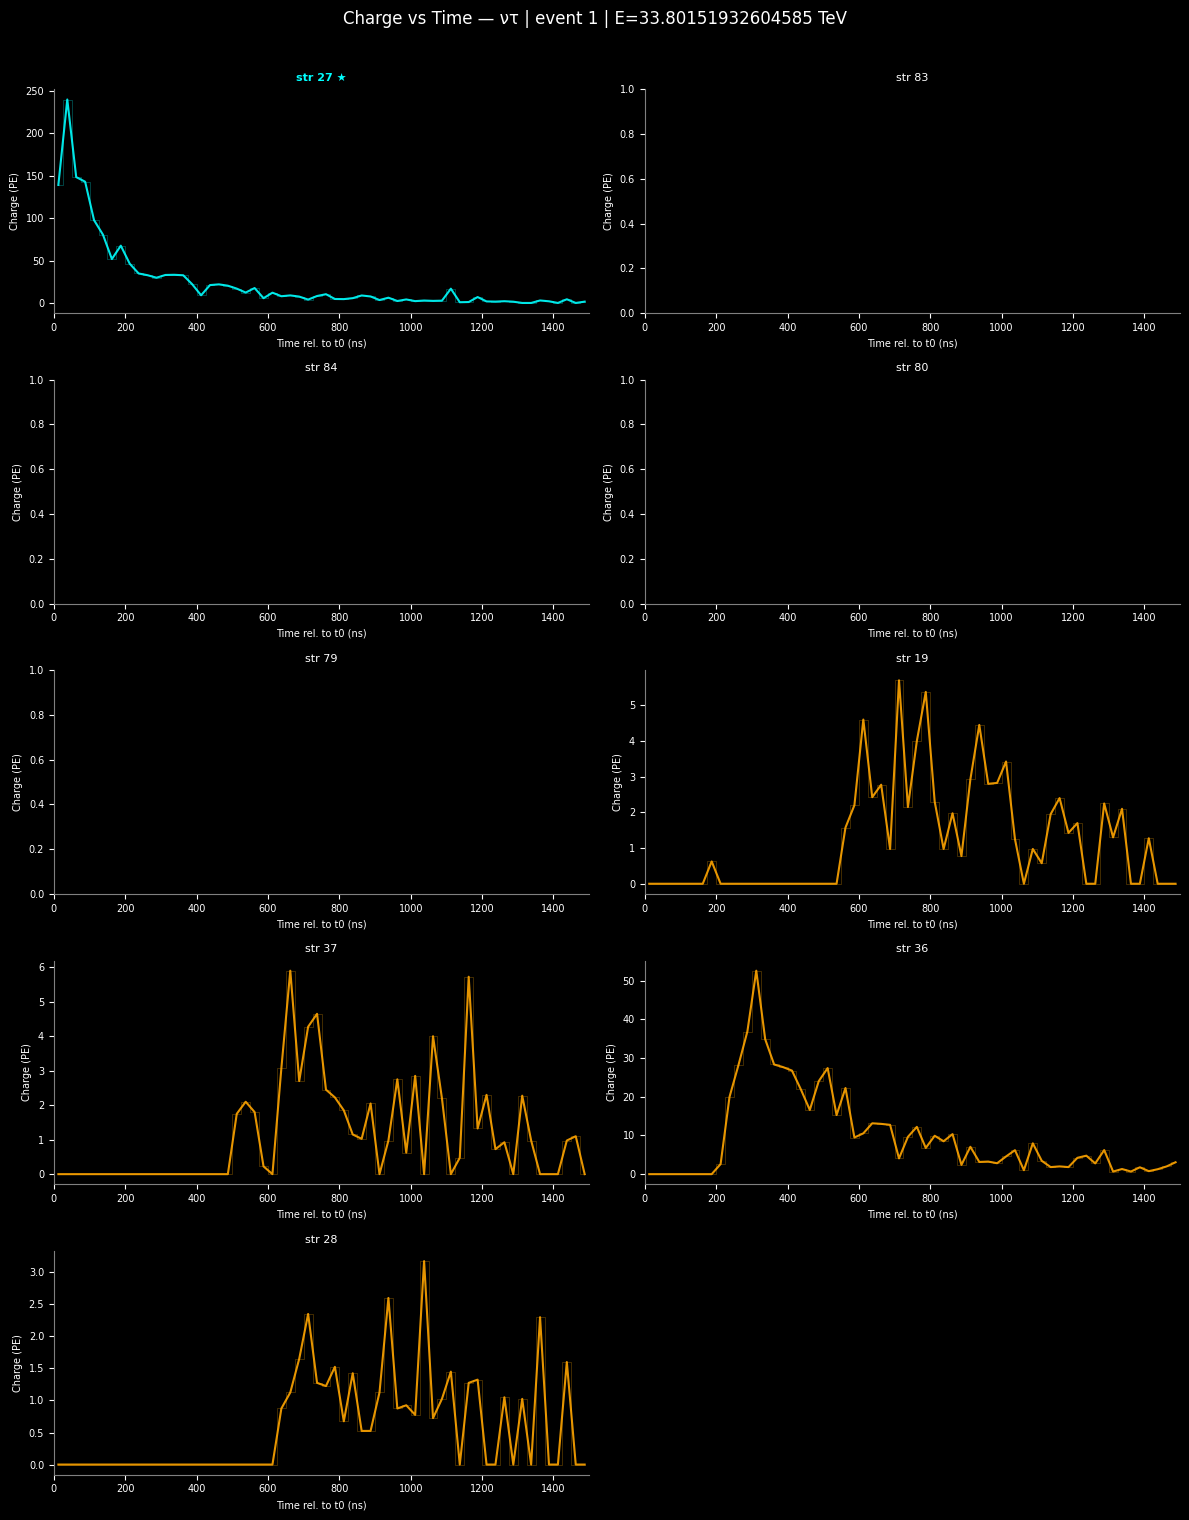

t0 = -75.00 ns  |  cut at 1425.00 ns


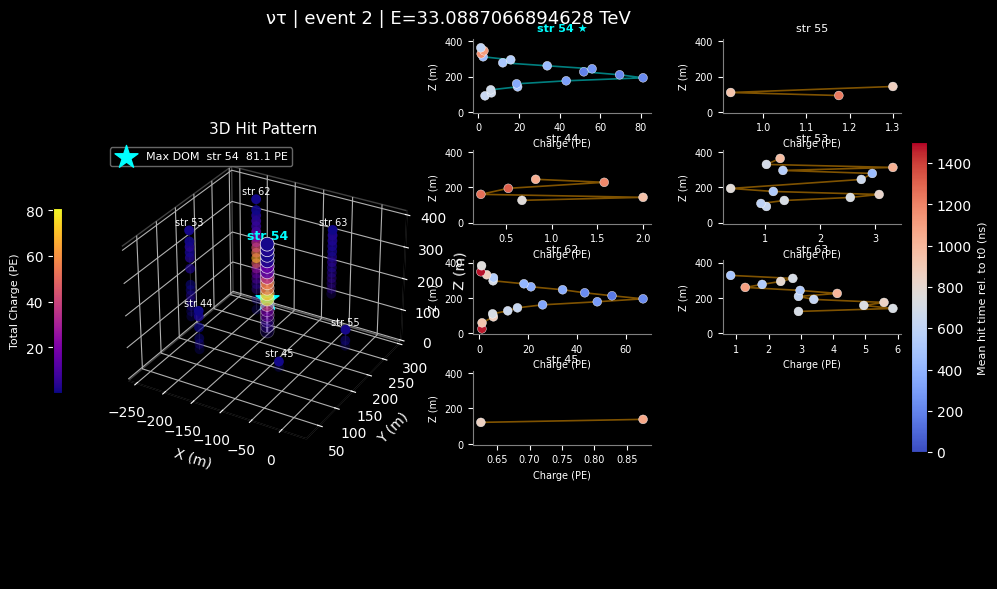

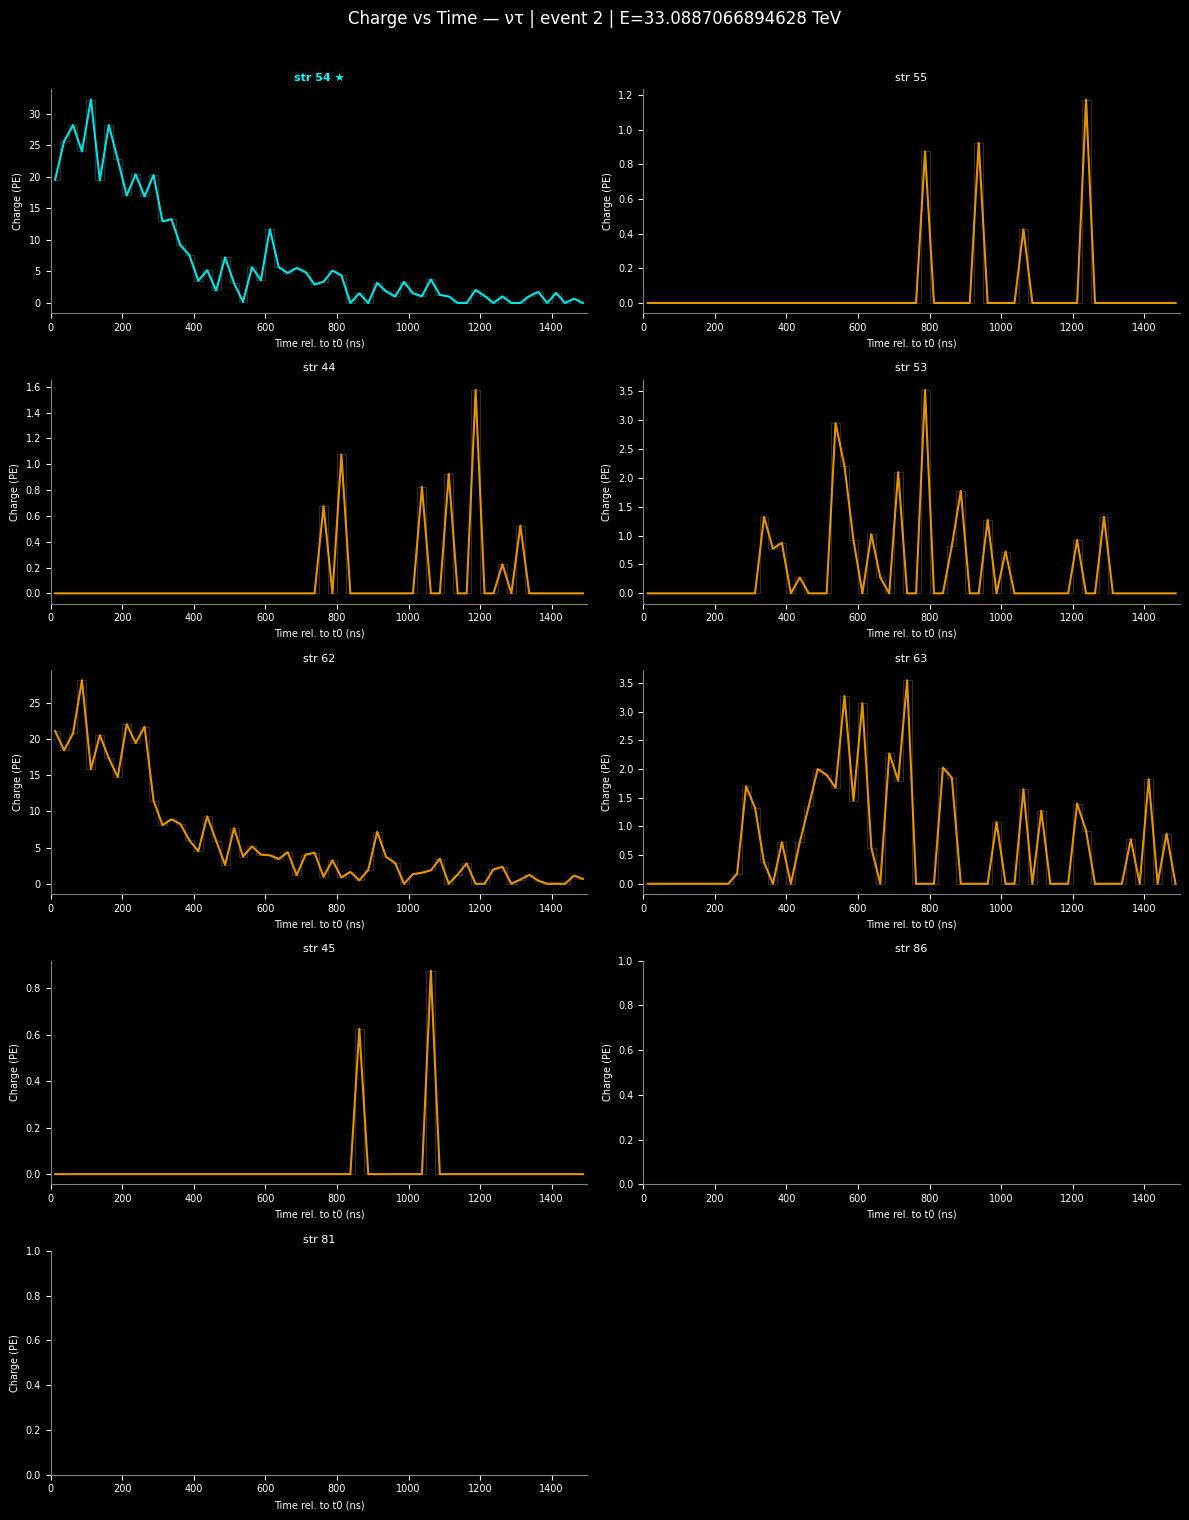

t0 = -66.00 ns  |  cut at 1434.00 ns


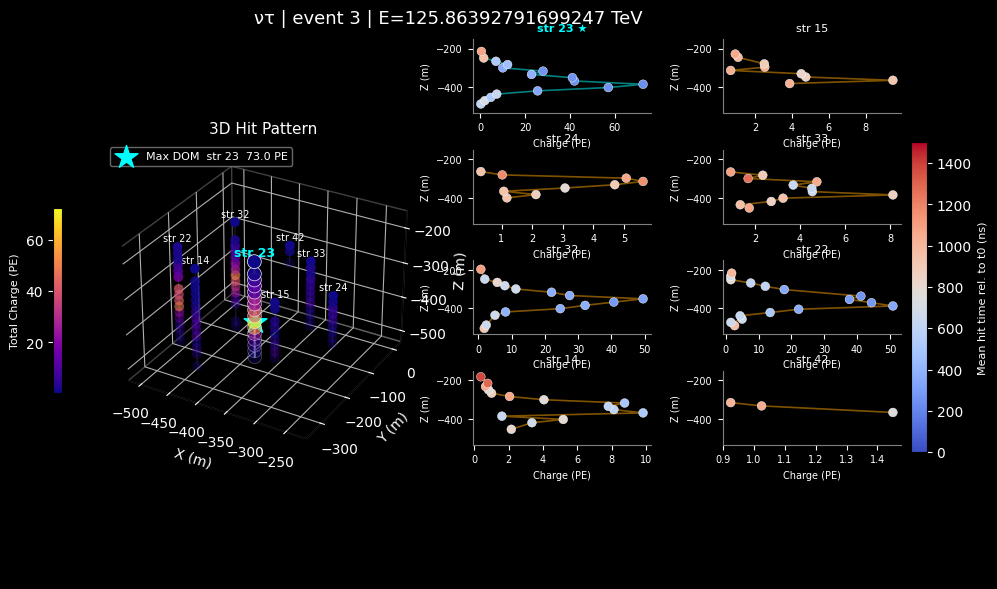

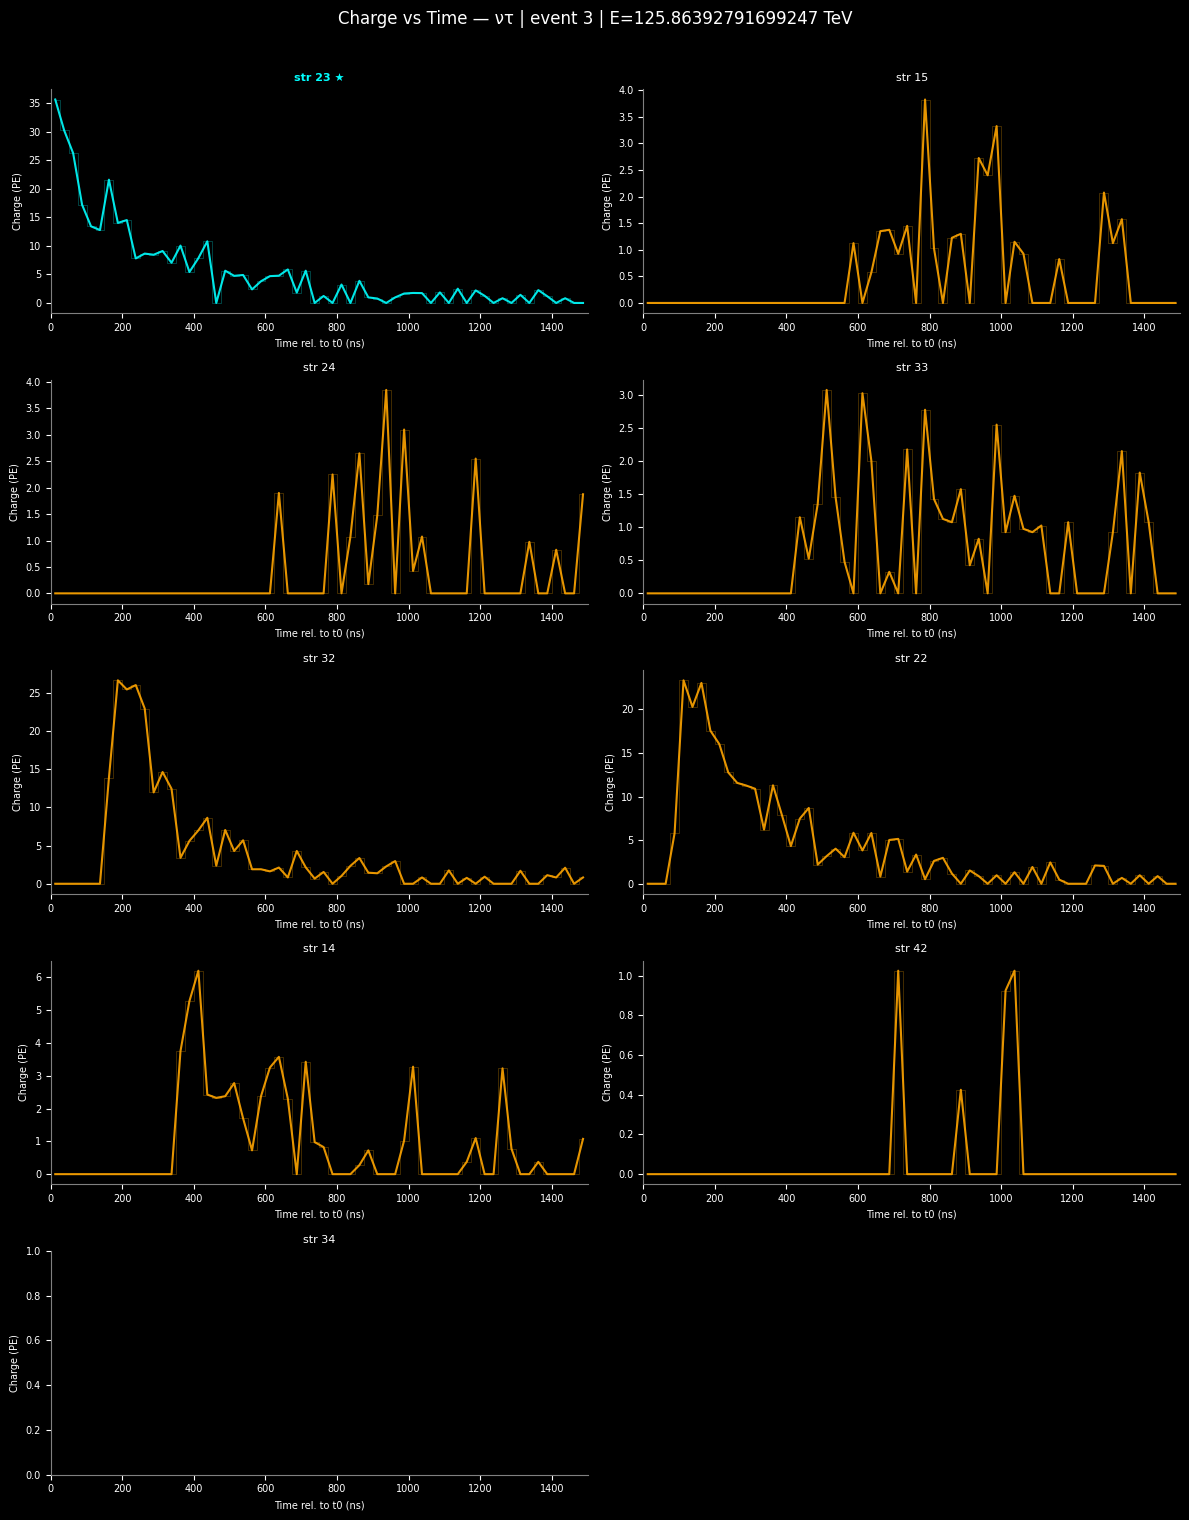

t0 = 40.00 ns  |  cut at 1540.00 ns


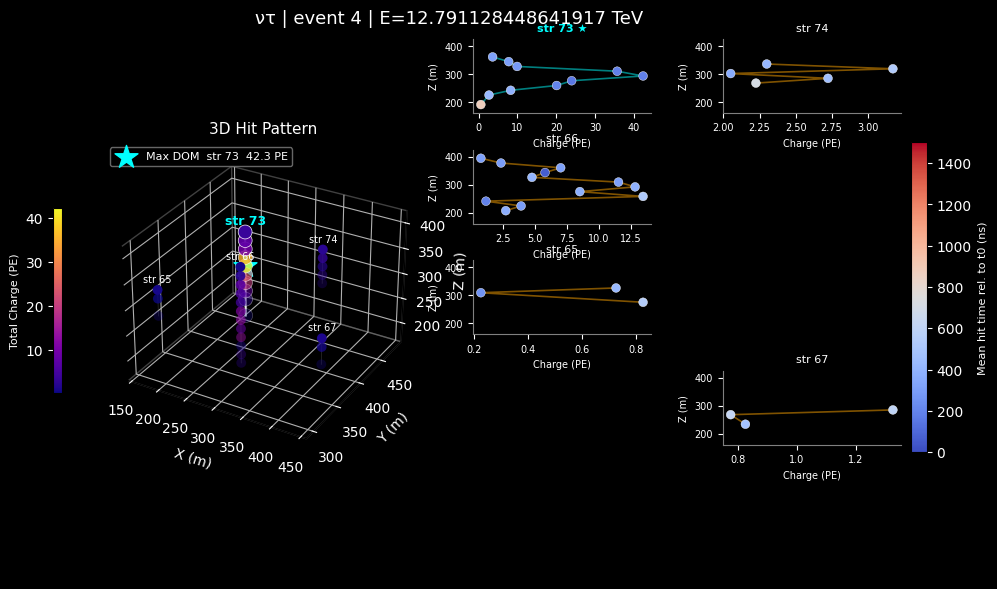

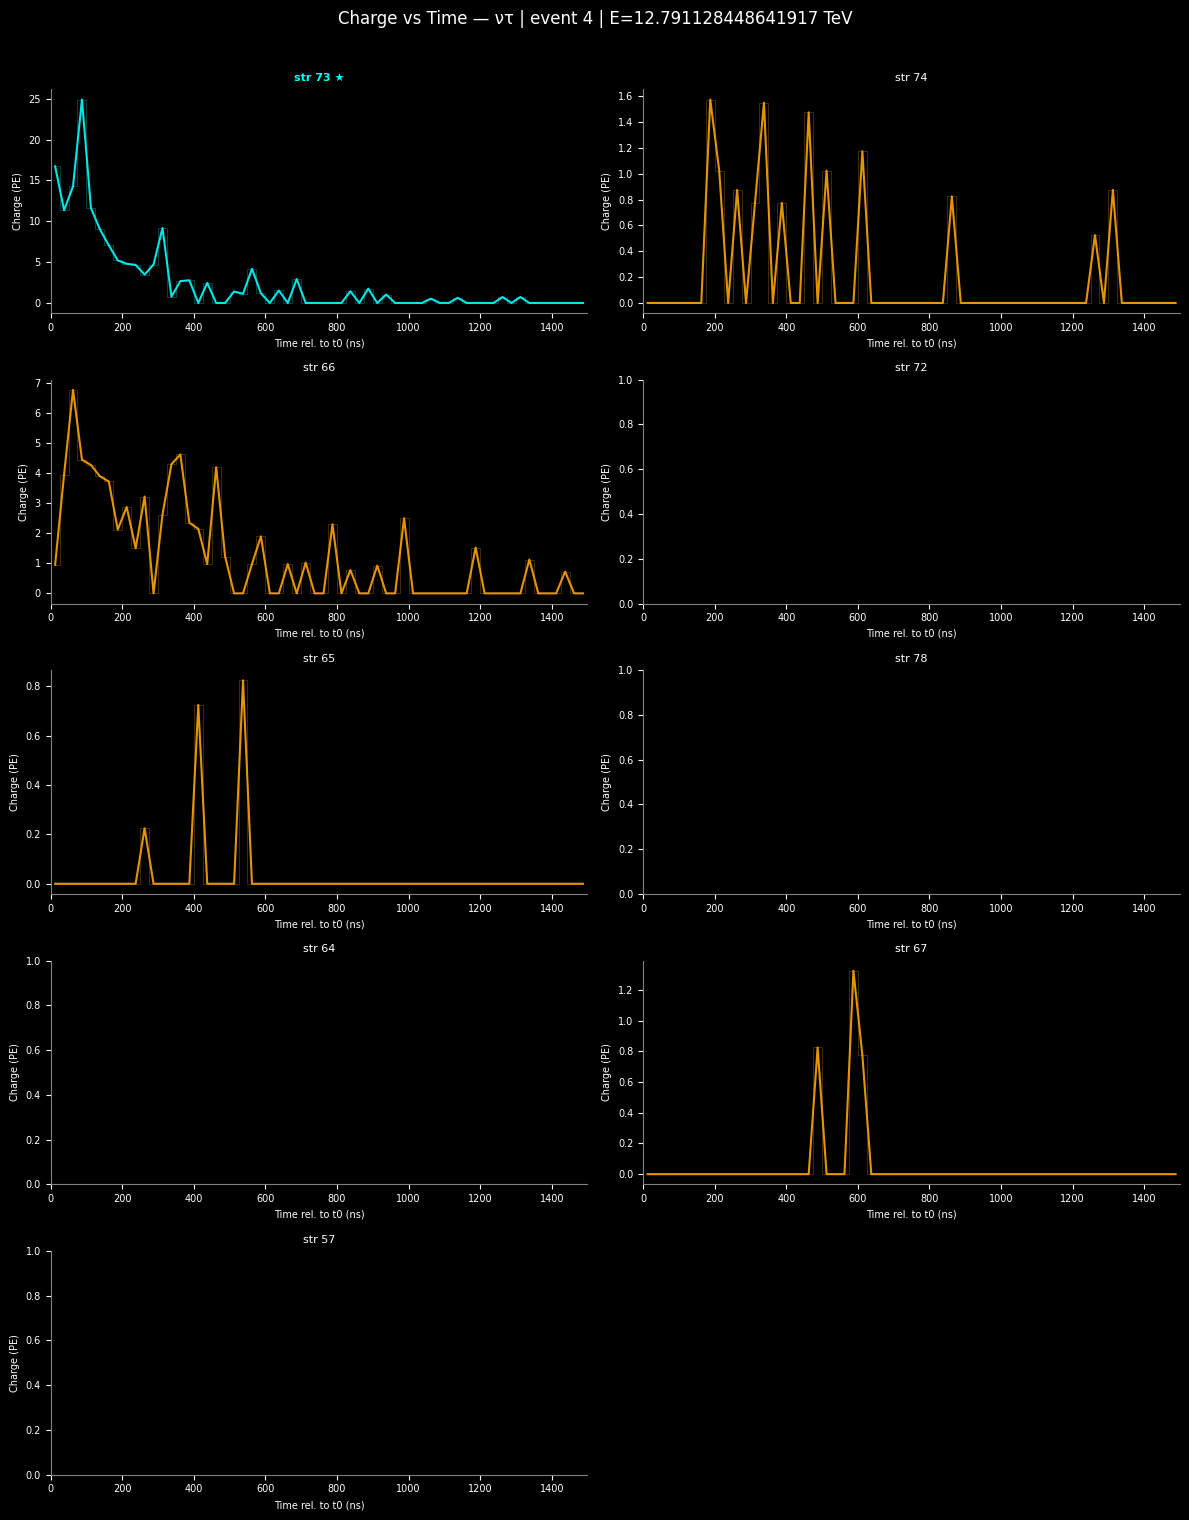

In [12]:
print("nue events:", df_nue.event_no.nunique())
print("nutau events:", df_nutau.event_no.nunique())
for i in range(0, 5):
    eid_tau = list(events_tau.keys())[i]
    plot_nearest_strings(
        events_tau[eid_tau], geo, n_surrounding=8,
        title=f"ντ | event {eid_tau} | E={events_tau[eid_tau].energy.iloc[0]/1e3} TeV"
    )
    # plt.savefig(f"Event{i}.png")

# # --- Plot ---
# eid_tau = list(events_tau.keys())[8]
# eid_nue = list(events_nue.keys())[8]

# plot_nearest_strings(
#     events_tau[eid_tau], geo, n_surrounding=8,
#     title=f"ντ | event {eid_tau} | E={events_tau[eid_tau].energy.iloc[0]/1e3} TeV"
# )
# plot_nearest_strings(
#     events_nue[eid_nue], geo, n_surrounding=8,
#     title=f"νₑ | event {eid_nue} | E={events_nue[eid_nue].energy.iloc[0]/1e3} TeV"
# )

In [ ]:

# --- Run ---
eid_tau = list(events_tau.keys())[8]
eid_nue = list(events_nue.keys())[8]

plot_asymmetry_comparison(
    events_tau[eid_tau],
    events_nue[eid_nue],
    geo, n_surrounding=6
)

In [ ]:
# def time_clustering_features(event_df, threshold=50, t_min=-200, t_max=1500):
#     t = event_df.dom_time.values
#     q = event_df.charge.values
#     x = event_df[["dom_x","dom_y","dom_z"]].values

#     # --- time window cut ---
#     mask = (t >= t_min) & (t <= t_max)
#     t, q, x = t[mask], q[mask], x[mask]

#     if len(t) < 2:
#         return 1, 0.0, 0.0, 0.0

#     idx = np.argsort(t)
#     t, x, q = t[idx], x[idx], q[idx]
#     t = t - t.min()

#     dt = np.diff(t)
#     cluster_id = np.zeros(len(t), dtype=int)
#     for i in range(1, len(t)):
#         if dt[i-1] > threshold:
#             cluster_id[i] = cluster_id[i-1] + 1
#         else:
#             cluster_id[i] = cluster_id[i-1]

#     clusters = np.unique(cluster_id)
#     cluster_stats = []
#     for c in clusters[:2]:
#         mask = cluster_id == c
#         q_c = q[mask]
#         t_c = t[mask]
#         x_c = x[mask]
#         q_sum = q_c.sum()
#         t_mean = (q_c * t_c).sum() / (q_sum + 1e-6)
#         x_mean = (q_c[:, None] * x_c).sum(axis=0) / (q_sum + 1e-6)
#         cluster_stats.append((x_mean, t_mean, q_sum))

#     if len(cluster_stats) < 2:
#         return 1, 0.0, 0.0, 0.0

#     (x1, t1, q1), (x2, t2, q2) = cluster_stats
#     dt = abs(t2 - t1)
#     dr = np.linalg.norm(x2 - x1)
#     ratio = q2 / (q1 + q2 + 1e-6)
#     return len(clusters), dt, dr, ratio


# def build_features(events):
#     rows = []
#     for eid, ev in events.items():
#         n_clusters, dt, dr, ratio = time_clustering_features(ev)
#         rows.append({
#             "event_no": eid,
#             "energy": ev.energy.iloc[0],
#             "pid": ev.pid.iloc[0],
#             "n_clusters": n_clusters,
#             "dt": dt,
#             "dr": dr,
#             "charge_ratio": ratio
#         })
#     return pd.DataFrame(rows)

# feat_nue = build_features(events_nue)
# feat_tau = build_features(events_tau)
def time_clustering_features(event_df, threshold=50, start_time=-200, time_window_length=1700):
    """
    Uses Finn's waveform logic: window from -200 ns to -200+1700 = 1500 ns.
    Hits outside this window are discarded before clustering.
    """
    t = event_df.dom_time.values
    q = event_df.charge.values
    x = event_df[["dom_x","dom_y","dom_z"]].values

    # --- Finn's time window logic ---
    stop_time = start_time + time_window_length  # -200 + 1700 = 1500 ns
    mask = (t >= start_time) & (t < stop_time)
    t, q, x = t[mask], q[mask], x[mask]

    if len(t) < 2:
        return 1, 0.0, 0.0, 0.0

    # Sort by time
    idx = np.argsort(t)
    t, x, q = t[idx], x[idx], q[idx]

    # Normalize time (keep relative, don't shift by start_time)
    t = t - t.min()

    # Time clustering
    dt_arr = np.diff(t)
    cluster_id = np.zeros(len(t), dtype=int)
    for i in range(1, len(t)):
        if dt_arr[i-1] > threshold:
            cluster_id[i] = cluster_id[i-1] + 1
        else:
            cluster_id[i] = cluster_id[i-1]

    clusters = np.unique(cluster_id)
    cluster_stats = []
    for c in clusters[:2]:
        c_mask = cluster_id == c
        q_c = q[c_mask]
        t_c = t[c_mask]
        x_c = x[c_mask]
        q_sum = q_c.sum()
        t_mean = (q_c * t_c).sum() / (q_sum + 1e-6)
        x_mean = (q_c[:, None] * x_c).sum(axis=0) / (q_sum + 1e-6)
        cluster_stats.append((x_mean, t_mean, q_sum))

    if len(cluster_stats) < 2:
        return 1, 0.0, 0.0, 0.0

    (x1, t1, q1), (x2, t2, q2) = cluster_stats
    dt = abs(t2 - t1)
    dr = np.linalg.norm(x2 - x1)
    ratio = q2 / (q1 + q2 + 1e-6)
    return len(clusters), dt, dr, ratio


def build_features(events):
    rows = []
    for eid, ev in events.items():
        n_clusters, dt, dr, ratio = time_clustering_features(ev)
        rows.append({
            "event_no": eid,
            "energy": ev.energy.iloc[0],
            "pid": ev.pid.iloc[0],
            "n_clusters": n_clusters,
            "dt": dt,
            "dr": dr,
            "charge_ratio": ratio
        })
    return pd.DataFrame(rows)

feat_nue = build_features(events_nue)
feat_tau = build_features(events_tau)

In [ ]:
plt.figure()
plt.hist(feat_tau.dt, bins=60, alpha=0.5, label="ντ")
plt.hist(feat_nue.dt, bins=60, alpha=0.5, label="νₑ")
plt.xlabel("Δt (ns)")
plt.ylabel("Counts")
plt.legend()
plt.title("Time separation (Δt)")
plt.show()

In [ ]:
plt.figure()
plt.hist(feat_tau.dr, bins=60, alpha=0.5, label="ντ")
plt.hist(feat_nue.dr, bins=60, alpha=0.5, label="νₑ")
plt.xlabel("Δr (m)")
plt.legend()
plt.title("Spatial separation (Δr)")
plt.show()

In [ ]:
plt.figure()
plt.hist(feat_tau.n_clusters, bins=20, alpha=0.5, label="ντ")
plt.hist(feat_nue.n_clusters, bins=20, alpha=0.5, label="νₑ")
plt.xlabel("Number of clusters")
plt.legend()
plt.show()

In [ ]:
plt.figure()
plt.scatter(feat_tau.energy, feat_tau.dt, s=5, alpha=0.3, label="ντ")
plt.scatter(feat_nue.energy, feat_nue.dt, s=5, alpha=0.3, label="νₑ")

plt.xscale("log")
plt.xlabel("Energy")
plt.ylabel("Δt")
plt.legend()
plt.title("Δt vs Energy")
plt.show()

In [ ]:
def plot_event(event_df, title=""):
    t = event_df.dom_time.values
    q = event_df.charge.values

    t = t - t.min()

    plt.scatter(t, q, s=5)
    plt.yscale("log")
    plt.xlabel("Time")
    plt.ylabel("Charge")
    plt.title(title)
def plot_with_clusters(event_df, threshold=10, title=""):
    t = event_df.dom_time.values
    q = event_df.charge.values
    
    idx = np.argsort(t)
    t = t[idx] - t.min()
    q = q[idx]

    dt = np.diff(t)
    cluster = np.zeros(len(t), dtype=int)

    for i in range(1, len(t)):
        if dt[i-1] > threshold:
            cluster[i] = cluster[i-1] + 1
        else:
            cluster[i] = cluster[i-1]

    plt.scatter(t, q, c=cluster, s=5)
    plt.xlabel("Time (ns)")
    plt.ylabel("Charge")
    plt.title(title)
    plt.yscale("log")

In [ ]:
print(f"length of tau events: {len(events_tau)}")
print(f"length of electron events: {len(events_nue)}")

In [ ]:
for i in range(min(5, len(events_tau), len(events_nue))):
    plt.figure(figsize=(10,6))

    # tau
    ev_tau = list(events_tau.values())[i]
    E_tau = ev_tau.energy.iloc[0]   # ✅ NOT [i]

    plt.subplot(2,2,1)
    plot_event(ev_tau, f"ντ | E={E_tau:.2e}")

    plt.subplot(2,2,2)
    plot_with_clusters(ev_tau, threshold=50,
                       title=f"ντ clusters | E={E_tau:.2e}")

    # nue
    ev_nue = list(events_nue.values())[i]
    E_nue = ev_nue.energy.iloc[0]   # ✅ NOT [i]

    plt.subplot(2,2,3)
    plot_event(ev_nue, f"νₑ | E={E_nue:.2e}")

    plt.subplot(2,2,4)
    plot_with_clusters(ev_nue, threshold=50,
                       title=f"νₑ clusters | E={E_nue:.2e}")

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_charge_per_dom_on_strings(event_df, geo, ax, title=""):
    """
    For a single event, merge hits with geometry to get string number,
    sum charge per DOM, then plot each string as a vertical line with
    DOMs colored by total charge.
    """
    # Sum charge per DOM position
    dom_charge = (
        event_df.groupby(["dom_x", "dom_y", "dom_z"])["charge"]
        .sum()
        .reset_index()
        .rename(columns={"charge": "total_charge"})
    )

    # Merge with geometry to get string number
    merged = dom_charge.merge(
        geo[["dom_x", "dom_y", "dom_z", "string"]],
        on=["dom_x", "dom_y", "dom_z"],
        how="left"
    )

    # Shared colormap across all DOMs in this event
    vmin = merged.total_charge.min()
    vmax = merged.total_charge.max()
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.hot

    # Plot each string as a vertical line, DOMs as scatter colored by charge
    for s, grp in merged.groupby("string"):
        # Draw a faint vertical line along the string (z extent)
        x0, y0 = grp.dom_x.iloc[0], grp.dom_y.iloc[0]
        ax.plot(
            [x0] * 2, [grp.dom_z.min(), grp.dom_z.max()],
            color="gray", lw=0.5, alpha=0.4, zorder=0
        )
        # Plot hit DOMs colored by charge
        sc = ax.scatter(
            grp.dom_x, grp.dom_z,
            c=grp.total_charge,
            cmap=cmap, norm=norm,
            s=40, zorder=2, edgecolors="none"
        )
        # Label string at top
        ax.text(
            x0, grp.dom_z.max() + 10, f"{int(s)}",
            fontsize=6, ha="center", color="steelblue", alpha=0.7
        )

    # Also draw unhit DOMs from geometry in the background
    hit_doms = set(zip(merged.dom_x, merged.dom_y, merged.dom_z))
    geo_unhit = geo[~geo.apply(
        lambda r: (r.dom_x, r.dom_y, r.dom_z) in hit_doms, axis=1
    )]
    ax.scatter(
        geo_unhit.dom_x, geo_unhit.dom_z,
        c="lightgray", s=4, zorder=1, edgecolors="none", alpha=0.3
    )

    ax.set_xlabel("X (m)", fontsize=10)
    ax.set_ylabel("Z (m)", fontsize=10)
    ax.set_title(title, fontsize=11)

    return sc, norm, cmap


# --- Pick one event from each ---
ev_idx = 4
ev_tau = list(events_tau.values())[ev_idx]
ev_nue = list(events_nue.values())[ev_idx]
E_tau  = ev_tau.energy.iloc[0]
E_nue  = ev_nue.energy.iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

sc_tau, norm, cmap = plot_charge_per_dom_on_strings(
    ev_tau, geo, axes[0], title=f"ντ  |  E = {E_tau:.2e} GeV"
)
sc_nue, _, _       = plot_charge_per_dom_on_strings(
    ev_nue, geo, axes[1], title=f"νₑ  |  E = {E_nue:.2e} GeV"
)

# Shared colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation="vertical", fraction=0.02, pad=0.02)
cbar.set_label("Total Charge (PE)", fontsize=11)

fig.suptitle("Charge Distribution per DOM on Strings", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
def radial_extent(ev):
    x = ev[["dom_x","dom_y","dom_z"]].values
    q = ev.charge.values

    center = (q[:,None]*x).sum(axis=0)/q.sum()
    r = np.linalg.norm(x - center, axis=1)

    return np.sqrt((q*(r**2)).sum()/q.sum())

r_tau = [radial_extent(ev) for ev in events_tau.values()]
r_nue = [radial_extent(ev) for ev in events_nue.values()]

plt.hist(r_tau, bins=50, alpha=0.5, label="ντ")
plt.hist(r_nue, bins=50, alpha=0.5, label="νₑ")

plt.legend()
plt.title("Radial spread")

In [ ]:
print(np.percentile(feat_tau.energy, [0, 25, 50, 75, 100]))

In [ ]:
def plot_time_hist(events, label):
    all_t = []
    for ev in events.values():
        t = ev.dom_time.values - ev.dom_time.min()
        all_t.extend(t)

    plt.hist(all_t, bins=200, density=True, alpha=0.5, label=label)

plot_time_hist(events_nue, "νₑ")
plot_time_hist(events_tau, "ντ")

plt.legend()
plt.xlabel("Time (ns)")
plt.ylabel("Density")
plt.title("Time distribution comparison")

In [ ]:
def plot_cumulative(ev):
    t = ev.dom_time.values
    q = ev.charge.values

    idx = np.argsort(t)
    t = t[idx] - t.min()
    q = q[idx]

    cum_q = np.cumsum(q) / q.sum()

    plt.plot(t, cum_q)

# plot few
for ev in list(events_nue.values())[:10]:
    plot_cumulative(ev)

plt.title("νₑ cumulative charge")

In [ ]:
def plot_cumulative(ev):
    t = ev.dom_time.values
    q = ev.charge.values

    idx = np.argsort(t)
    t = t[idx] - t.min()
    q = q[idx]

    cum_q = np.cumsum(q) / q.sum()

    plt.plot(t, cum_q)

# plot few
for ev in list(events_tau.values())[:10]:
    plot_cumulative(ev)

plt.title("ντ cumulative charge")

In [ ]:
def compute_width(ev):
    t = ev.dom_time.values
    q = ev.charge.values

    t = t - t.min()
    mean = (q*t).sum()/q.sum()
    std  = np.sqrt((q*(t-mean)**2).sum()/q.sum())

    return std

width_tau = [compute_width(ev) for ev in events_tau.values()]
E_tau     = [ev.energy.iloc[0] for ev in events_tau.values()]

width_nue = [compute_width(ev) for ev in events_nue.values()]
E_nue     = [ev.energy.iloc[0] for ev in events_nue.values()]

plt.scatter(E_tau, width_tau, s=5, alpha=0.3, label="ντ")
plt.scatter(E_nue, width_nue, s=5, alpha=0.3, label="νₑ")

plt.xscale("log")
plt.xlabel("Energy")
plt.ylabel("Time width")
plt.legend()

In [ ]:
def skewness(ev):
    t = ev.dom_time.values
    q = ev.charge.values

    t = t - t.min()
    mean = (q*t).sum()/q.sum()
    std  = np.sqrt((q*(t-mean)**2).sum()/q.sum())

    skew = (q*(t-mean)**3).sum() / (q.sum()*std**3 + 1e-6)
    return skew

skew_tau = [skewness(ev) for ev in events_tau.values()]
skew_nue = [skewness(ev) for ev in events_nue.values()]

plt.hist(skew_tau, bins=50, alpha=0.5, label="ντ")
plt.hist(skew_nue, bins=50, alpha=0.5, label="νₑ")

plt.legend()
plt.title("Skewness distribution")

In [ ]:
plt.scatter(width_tau, skew_tau, alpha=0.3, label="ντ")
plt.scatter(width_nue, skew_nue, alpha=0.3, label="νₑ")

plt.xlabel("Width")
plt.ylabel("Skewness")
plt.legend()

In [ ]:
all_dt = []

for ev in events_tau.values():
    t = np.sort(ev.dom_time.values)
    all_dt.extend(np.diff(t))

plt.hist(all_dt, bins=200, log=True)
plt.xlabel("Δt between hits (ns)")
plt.ylabel("Counts")
plt.title("Global dt distribution")
plt.show()

In [ ]:
connection = sqlite3.connect("/mnt/scratch/baburish/doublepulse/gnn/files/output/nue/nue_pisces_5TeV_lowerbound_skimmed_chunk_022856.000009_0001.db")
sql_query = """SELECT name FROM sqlite_master  
  WHERE type='table';"""
cursor = connection.cursor()
cursor.execute(sql_query)
output = cursor.fetchall()
print(output)
df_truth = pd.read_sql_query("SELECT * FROM truth;", connection)
df_pulses = pd.read_sql_query("SELECT * FROM CleanedROIPulses;", connection)
connection.close()

In [ ]:
df_truth.head()
print(f"Number of duplicated event_no (excluding first occurrence): {df_truth.duplicated(subset='event_no').sum()}")

In [ ]:
df_pulses.head()
print(f"Number of duplicated event_no (excluding first occurrence): {df_pulses.duplicated(subset='event_no').sum()}")

In [ ]:
print(len(df_truth))
print(len(df_pulses))

In [ ]:
df_truth.columns

In [ ]:
df = df_pulses.merge(
    df_truth[["event_no", "energy", "pid"]],
    on="event_no",
    how="inner"
)

print("Total rows:", len(df))
print("Total events:", df.event_no.nunique())
df.head()

In [ ]:
events = dict(tuple(df.groupby("event_no")))

print("Number of events:", len(events))

In [ ]:
def plot_charge_time(event_df, title=""):
    t = event_df.dom_time.values
    q = event_df.charge.values

    t = t - t.min()

    plt.figure()
    plt.scatter(t, q, s=5)
    plt.xlabel("Time (ns)")
    plt.ylabel("Charge")
    plt.yscale("log")
    plt.title(title)
    plt.show()
def plot_with_clusters(event_df, threshold=30):
    t = event_df.dom_time.values
    q = event_df.charge.values

    idx = np.argsort(t)
    t = t[idx] - t.min()
    q = q[idx]

    dt = np.diff(t)
    cluster = np.zeros(len(t), dtype=int)

    for i in range(1, len(t)):
        if dt[i-1] > threshold:
            cluster[i] = cluster[i-1] + 1
        else:
            cluster[i] = cluster[i-1]

    plt.figure()
    plt.scatter(t, q, c=cluster, s=5)
    plt.xlabel("Time (ns)")
    plt.ylabel("Charge")
    plt.yscale("log")
    plt.title("Clustered pulses")
    plt.show()
def time_clustering_features(event_df, threshold=30):
    t = event_df.dom_time.values
    q = event_df.charge.values
    x = event_df[["dom_x","dom_y","dom_z"]].values

    idx = np.argsort(t)
    t, x, q = t[idx], x[idx], q[idx]

    t = t - t.min()

    dt = np.diff(t)
    cluster_id = np.zeros(len(t), dtype=int)

    for i in range(1, len(t)):
        if dt[i-1] > threshold:
            cluster_id[i] = cluster_id[i-1] + 1
        else:
            cluster_id[i] = cluster_id[i-1]

    clusters = np.unique(cluster_id)

    cluster_stats = []

    for c in clusters[:2]:
        mask = cluster_id == c

        q_c = q[mask]
        t_c = t[mask]
        x_c = x[mask]

        q_sum = q_c.sum()
        t_mean = (q_c * t_c).sum() / (q_sum + 1e-6)
        x_mean = (q_c[:, None] * x_c).sum(axis=0) / (q_sum + 1e-6)

        cluster_stats.append((x_mean, t_mean, q_sum))

    if len(cluster_stats) < 2:
        return 1, 0.0, 0.0, 0.0

    (x1, t1, q1), (x2, t2, q2) = cluster_stats

    dt = abs(t2 - t1)
    dr = np.linalg.norm(x2 - x1)
    ratio = q2 / (q1 + q2 + 1e-6)

    return len(clusters), dt, dr, ratio

In [ ]:
for eid in list(events.keys())[:5]:
    ev = events[eid]
    energy = ev.energy.iloc[0]
    pid = ev.pid.iloc[0]

    plot_charge_time(ev, f"PID={pid}, E={energy:.2e}")
    plot_with_clusters(ev)

In [ ]:
features = []

for event_id, ev in events.items():
    n_clusters, dt, dr, ratio = time_clustering_features(ev)

    features.append({
        "event_no": event_id,
        "energy": ev.energy.iloc[0],
        "pid": ev.pid.iloc[0],
        "n_clusters": n_clusters,
        "dt": dt,
        "dr": dr,
        "charge_ratio": ratio
    })

feat_df = pd.DataFrame(features)

feat_df.head()

In [ ]:
plt.figure()
plt.hist(feat_df.dt, bins=50)
plt.xlabel("Δt")
plt.title("Δt distribution (sanity check)")
plt.show()

## Vertex conversion and direction plot (global → detector coordinates)
This cell estimates a translation from truth global coordinates (`position_x`, `position_y`, `position_z`) to IceCube detector coordinates using charge-weighted DOM centroids, then plots one event in 3D with its direction vector from (`azimuth`, `zenith`).

In [ ]:
# --- Global -> detector conversion + direction plot ---
import numpy as np
import matplotlib.pyplot as plt


def estimate_global_to_detector_shift(df, max_events=2000):
    """
    Estimate translation vector such that:
        detector_xyz ~= global_xyz - shift
    using charge-weighted DOM centroids per event.
    """
    shifts = []

    for event_no, ev in df.groupby("event_no"):
        if len(shifts) >= max_events:
            break

        q = ev["charge"].to_numpy(dtype=float)
        if q.sum() <= 0:
            continue

        dom_xyz = ev[["dom_x", "dom_y", "dom_z"]].to_numpy(dtype=float)
        centroid = (q[:, None] * dom_xyz).sum(axis=0) / (q.sum() + 1e-9)

        global_vertex = ev[["position_x", "position_y", "position_z"]].iloc[0].to_numpy(dtype=float)
        shifts.append(global_vertex - centroid)

    shifts = np.array(shifts)
    shift_median = np.median(shifts, axis=0)
    return shift_median, shifts


def direction_vector_from_az_zen(azimuth, zenith):
    """
    Unit vector from azimuth/zenith.
    If your convention is opposite (incoming vs outgoing), multiply by -1.
    """
    dx = np.sin(zenith) * np.cos(azimuth)
    dy = np.sin(zenith) * np.sin(azimuth)
    dz = np.cos(zenith)
    vec = np.array([dx, dy, dz], dtype=float)
    return vec / (np.linalg.norm(vec) + 1e-12)


# 1) Estimate transform from currently loaded sample
shift, all_shifts = estimate_global_to_detector_shift(df_nutau, max_events=2000)
print(f"Estimated global->detector shift: x={shift[0]:.2f}, y={shift[1]:.2f}, z={shift[2]:.2f}")

# 2) Pick one event and convert vertex
event_no = int(df_nutau.event_no.iloc[0])
ev = events_tau[event_no]

vertex_global = ev[["position_x", "position_y", "position_z"]].iloc[0].to_numpy(dtype=float)
vertex_det = vertex_global - shift

az = float(ev["azimuth"].iloc[0])
ze = float(ev["zenith"].iloc[0])
dir_vec = direction_vector_from_az_zen(az, ze)

# 3) Plot event DOMs + converted vertex + direction
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# event hits
q = ev["charge"].to_numpy(dtype=float)
sc = ax.scatter(
    ev["dom_x"], ev["dom_y"], ev["dom_z"],
    c=np.log1p(q), cmap="viridis", s=18, alpha=0.85, label="hit DOMs"
)

# converted vertex
ax.scatter(
    [vertex_det[0]], [vertex_det[1]], [vertex_det[2]],
    color="red", s=120, marker="*", label="converted vertex"
)

# direction arrow
arrow_len = 250.0  # meters
ax.quiver(
    vertex_det[0], vertex_det[1], vertex_det[2],
    dir_vec[0], dir_vec[1], dir_vec[2],
    length=arrow_len, normalize=True, color="orange", linewidth=2
)

ax.set_xlabel("X (detector m)")
ax.set_ylabel("Y (detector m)")
ax.set_zlabel("Z (detector m)")
ax.set_title(f"Event {event_no} in detector coordinates + direction")
ax.legend(loc="upper left")
fig.colorbar(sc, ax=ax, pad=0.1, shrink=0.7, label="log(1+charge)")
plt.tight_layout()
plt.show()


In [ ]:
# Quick diagnostic: compare ranges of global vertex and detector DOM coordinates
print("DOM ranges (m):")
print("  x:", float(df_nutau.dom_x.min()), float(df_nutau.dom_x.max()))
print("  y:", float(df_nutau.dom_y.min()), float(df_nutau.dom_y.max()))
print("  z:", float(df_nutau.dom_z.min()), float(df_nutau.dom_z.max()))

print("Vertex ranges (raw):")
print("  x:", float(df_nutau.position_x.min()), float(df_nutau.position_x.max()))
print("  y:", float(df_nutau.position_y.min()), float(df_nutau.position_y.max()))
print("  z:", float(df_nutau.position_z.min()), float(df_nutau.position_z.max()))

med_dom = df_nutau[["dom_x", "dom_y", "dom_z"]].median().to_numpy()
med_pos = df_nutau[["position_x", "position_y", "position_z"]].median().to_numpy()
print("Median (vertex/dom) ratio per axis:", med_pos / (med_dom + 1e-9))